# Предсказание незачёта: топ-K студентов по риску и три признака

**Постановка.** Дана анкета студента, заполненная в начале года. Требуется
ранжировать группу по риску не набрать проходной балл и назвать признаки,
на которых держится это ранжирование. Два результата:

1. **Топ-K студентов по риску** — ранжированный список, отсекаемый по K.
2. **Три признака с наибольшей важностью** — с направлением и оценкой
   устойчивости.

**Данные.** 649 студентов, курс португальского языка. Итоговый балл `G3` по
20-балльной шкале, порог зачёта — 10. Ниже порога 100 человек, 15.4 % группы.
Второй файл — 395 студентов по математике — используется для проверки
переноса на другой предмет.

## Метрики

Accuracy не используется: константный прогноз «зачёт» даёт 85 % и нулевой
recall на целевом классе. Качество измеряется двумя величинами:

* **ROC-AUC** — вероятность того, что случайно взятый положительный случай
  получит более высокий ранг, чем случайно взятый отрицательный.
  0.5 — случайное ранжирование, 1.0 — полное разделение.
* **PR-AUC** — площадь под кривой precision–recall. Базовый уровень
  для сравнения — 0.154, доля положительного класса.

**Каждая величина приводится с разбросом**, например `0.826 ± 0.043`:
20 разбиений на обучение и проверку, ± — стандартное отклонение между ними.
При n = 649 разница в 0.01 неотличима от смены случайного зерна.

## Структура

| Блоки | Содержание |
|---|---|
| 3–5 | Данные: проверки, целевая переменная, разбор 15 студентов с нулём |
| 6–8 | Подготовка признаков, протокол оценки, два уровня доступности данных |
| 9 | Сравнение десяти моделей на одних разбиениях |
| 10–14 | Настройка, конструирование признаков, регрессия, бленд, подтверждение |
| 15–17 | Три признака: важность, устойчивость, направление |
| 18–19 | Размер списка K и его recall. Сравнение с правилом без модели |
| 20–22 | Перенос на математику, техническая сводка, выгрузка модели |

## 2. Импорты и константы

Рабочая модель целиком на scikit-learn. Бустинги и нейросети участвуют
в сравнении моделей (блок 9), но в итоговое решение не входят — почему,
видно там же. Все источники случайности зафиксированы явно, значений
по умолчанию нет нигде.

In [1]:
import hashlib
import inspect
import json
import sys
import time
import warnings
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import rankdata

from sklearn.ensemble import (
    ExtraTreesClassifier,
    ExtraTreesRegressor,
    HistGradientBoostingClassifier,
    RandomForestClassifier,
    RandomForestRegressor,
)
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LogisticRegression, RidgeCV
from sklearn.metrics import (
    average_precision_score,
    precision_recall_curve,
    roc_auc_score,
)
from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

RANDOM_STATE = 42
N_SPLITS = 5
SELECT_SEED = 0          # фолды, на которых мы ОТБИРАЕМ варианты
CONFIRM_SEED = 1         # фолды, на которых ПОДТВЕРЖДАЕМ выбранное
PASS_MARK = 10           # порог зачёта по 20-балльной шкале

ROOT = Path.cwd()
POR_PATH = ROOT / "student-por.csv"
MAT_PATH = ROOT / "student-mat.csv"
CACHE_DIR = ROOT / "cache"
MODELS_DIR = ROOT / "models"
SRC_DIR = ROOT / "src"
CACHE_DIR.mkdir(exist_ok=True)

if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 160)
pd.set_option("display.float_format", lambda v: f"{v:.4f}")

plt.rcParams.update({
    "figure.dpi": 110,
    "figure.autolayout": True,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 10,
})

C_PASS = "#4C78A8"   # зачёт
C_FAIL = "#E45756"   # незачёт
C_NEUTRAL = "#8C8C8C"

# Русские подписи для графиков и таблиц.
RU = {
    "absences": "пропуски занятий", "studytime": "часы самоподготовки",
    "failures": "прошлые незачёты", "G1": "контрольная 1", "G2": "контрольная 2",
    "G3": "итоговый балл", "traveltime": "дорога до школы",
    "famrel": "отношения в семье", "freetime": "свободное время",
    "goout": "встречи с друзьями", "Dalc": "алкоголь в будни",
    "Walc": "алкоголь в выходные", "health": "здоровье", "age": "возраст",
    "Medu": "образование матери", "Fedu": "образование отца",
    "schoolsup": "доп. поддержка школы", "famsup": "поддержка семьи",
    "paid": "платные занятия", "higher": "планирует учиться дальше",
    "internet": "интернет дома", "romantic": "отношения",
    "activities": "кружки", "nursery": "ходил в садик",
    "school": "учебное заведение", "sex": "пол", "address": "город/село",
    "famsize": "размер семьи", "Pstatus": "родители вместе",
    "Mjob": "работа матери", "Fjob": "работа отца",
    "reason": "причина выбора", "guardian": "опекун",
    "alc_total": "алкоголь всего", "parent_edu": "образование родителей",
    "support_cnt": "число видов поддержки", "has_failed": "были незачёты",
    "abs_log": "пропуски (лог)", "abs_zero": "ни одного пропуска",
    "social": "гулянки × алкоголь", "age_over": "старше сверстников",
    "risk_combo": "связка риска", "study_ratio": "учёба на пропуск",
    "no_higher_x_fail": "не учится дальше × незачёты",
}

DATA_FP = None   # отпечаток данных, заполняется в блоке 3


def ru(name):
    """Русская подпись, включая one-hot имена вида `higher_yes`."""
    if name in RU:
        return RU[name]
    if "_" in name:
        base, _, level = name.rpartition("_")
        if base in RU:
            return f"{RU[base]} = {level}"
    return name


def cached(name, params, fn, verbose=True):
    """Результат fn(), сохранённый в cache/.

    Ключ — хеш от params и от отпечатка данных. Меняются параметры или файлы —
    ключ другой, кэш пересчитывается сам. Руками чистить ничего не нужно.
    """
    payload = json.dumps({"params": params, "data": DATA_FP},
                         sort_keys=True, default=str, ensure_ascii=False)
    key = hashlib.md5(payload.encode("utf-8")).hexdigest()[:12]
    path = CACHE_DIR / f"{name}__{key}.pkl"
    if path.exists():
        print(f"  [кэш]  {name} — взято из {path.name}")
        return joblib.load(path)
    t0 = time.perf_counter()
    value = fn()
    joblib.dump(value, path, compress=3)
    print(f"  [счёт] {name} — {time.perf_counter() - t0:.1f} с, сохранено в {path.name}")
    return value


print("scikit-learn", __import__("sklearn").__version__,
      "| pandas", pd.__version__, "| numpy", np.__version__)

scikit-learn 1.9.0 | pandas 3.0.5 | numpy 2.4.6


## 3. Загрузка и проверки

Прежде чем что-то предсказывать, надо убедиться, что таблица не сломана:
правильный ли размер, нет ли повторов, нет ли пустых клеток.

In [2]:
por = pd.read_csv(POR_PATH, sep=";")
mat = pd.read_csv(MAT_PATH, sep=";")

DATA_FP = {
    "por": hashlib.md5(POR_PATH.read_bytes()).hexdigest()[:10],
    "mat": hashlib.md5(MAT_PATH.read_bytes()).hexdigest()[:10],
}

checks = pd.DataFrame({
    "португальский": [por.shape[0], por.shape[1],
                      int(por.duplicated().sum()), int(por.isna().sum().sum())],
    "математика": [mat.shape[0], mat.shape[1],
                   int(mat.duplicated().sum()), int(mat.isna().sum().sum())],
}, index=["строк", "колонок", "полных дублей", "пустых клеток"])
print(checks.to_string())

assert por.shape == (649, 33) and mat.shape == (395, 33), "размер файла не тот"
assert por.isna().sum().sum() == 0 and mat.isna().sum().sum() == 0, "появились пропуски"
print(f"\nотпечаток данных: {DATA_FP}")

               португальский  математика
строк                    649         395
колонок                   33          33
полных дублей              0           0
пустых клеток              0           0

отпечаток данных: {'por': '973e7bacf3', 'mat': '4dc304be95'}


In [3]:
num_cols = [c for c in por.columns if por[c].dtype.kind in "iuf"]
cat_cols = [c for c in por.columns if c not in num_cols]
print(f"числовых колонок: {len(num_cols)}  ->  {', '.join(num_cols)}")
print(f"\nтекстовых колонок: {len(cat_cols)}  ->  {', '.join(cat_cols)}")
print("\nвсе текстовые колонки — категории с малым числом значений:")
print(por[cat_cols].nunique().to_frame("уникальных значений").T.to_string())

числовых колонок: 16  ->  age, Medu, Fedu, traveltime, studytime, failures, famrel, freetime, goout, Dalc, Walc, health, absences, G1, G2, G3

текстовых колонок: 17  ->  school, sex, address, famsize, Pstatus, Mjob, Fjob, reason, guardian, schoolsup, famsup, paid, activities, nursery, higher, internet, romantic

все текстовые колонки — категории с малым числом значений:
                     school  sex  address  famsize  Pstatus  Mjob  Fjob  reason  guardian  schoolsup  famsup  paid  activities  nursery  higher  internet  romantic
уникальных значений       2    2        2        2        2     5     5       4         3          2       2     2           2        2       2         2         2


In [4]:
y_por = (por["G3"] < PASS_MARK).astype(int)
y_mat = (mat["G3"] < PASS_MARK).astype(int)

print(f"португальский: незачётов {y_por.sum()} из {len(y_por)}  "
      f"({y_por.mean():.1%})")
print(f"математика:    незачётов {y_mat.sum()} из {len(y_mat)}  "
      f"({y_mat.mean():.1%})")
print(f"\nдоля незачётов 15 % — значит, «всем зачёт» даёт "
      f"{1 - y_por.mean():.0%} правильных ответов и ноль пользы.")
print("Поэтому accuracy в этом ноутбуке не встречается ни разу.")

португальский: незачётов 100 из 649  (15.4%)
математика:    незачётов 130 из 395  (32.9%)

доля незачётов 15 % — значит, «всем зачёт» даёт 85% правильных ответов и ноль пользы.
Поэтому accuracy в этом ноутбуке не встречается ни разу.


**Вывод.** Данные чистые: ни одной пустой клетки, ни одного полного дубля,
размеры совпадают с заявленными. Пропуски заполнять не нужно — заполнять нечего.
Незачётов 100 из 649 (15.4 %), классы сильно неравные, и это определяет
всё дальнейшее: и выбор метрик, и `class_weight='balanced'` в моделях.

## 4. Что видно в данных

Четыре картинки, каждая с одной строчкой вывода. Больше не нужно —
остальное всё равно проверяется моделью, а не глазами.

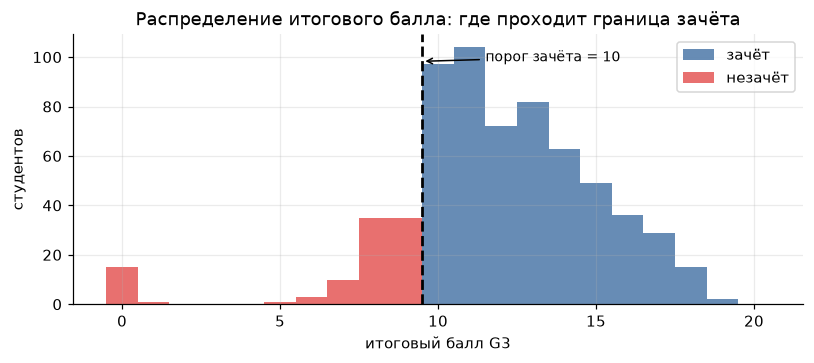

In [5]:
fig, ax = plt.subplots(figsize=(7.5, 3.4))
bins = np.arange(-0.5, 21.5, 1)
ax.hist(por.loc[y_por == 0, "G3"], bins=bins, color=C_PASS, alpha=0.85, label="зачёт")
ax.hist(por.loc[y_por == 1, "G3"], bins=bins, color=C_FAIL, alpha=0.85, label="незачёт")
ax.axvline(PASS_MARK - 0.5, color="black", lw=1.8, ls="--")
ax.annotate("порог зачёта = 10", xy=(PASS_MARK - 0.5, ax.get_ylim()[1] * 0.9),
            xytext=(11.5, ax.get_ylim()[1] * 0.9), fontsize=9,
            arrowprops=dict(arrowstyle="->", lw=1))
ax.set_xlabel("итоговый балл G3"); ax.set_ylabel("студентов")
ax.set_title("Распределение итогового балла: где проходит граница зачёта")
ax.legend()
plt.show()

**Вывод.** Балл распределён почти симметрично вокруг 11–12, и порог 10 режет
не пустоту, а плотную часть: очень многие стоят в одном-двух баллах от границы.
Отдельно торчит столбик на нуле — к нему вернёмся в блоке 5.

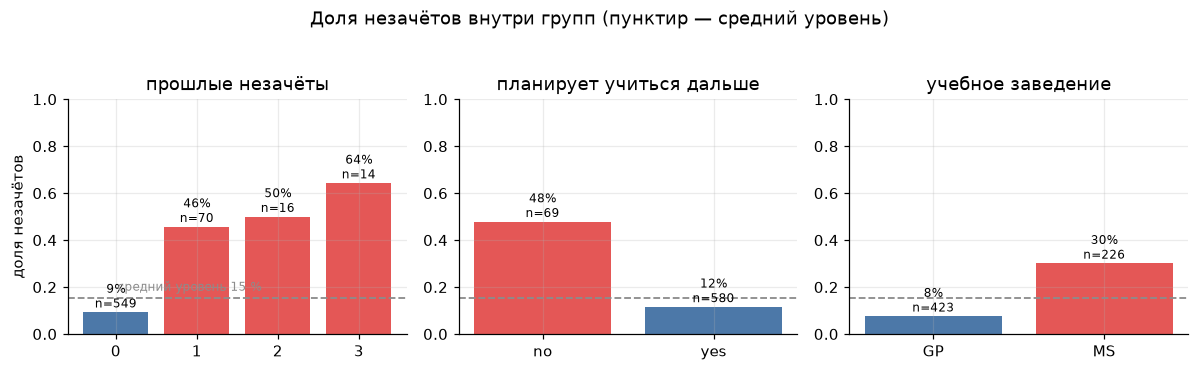

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(11, 3.2))
for ax, col in zip(axes, ["failures", "higher", "school"]):
    share = por.groupby(col, observed=True)["G3"].apply(
        lambda s: (s < PASS_MARK).mean())
    counts = por.groupby(col, observed=True).size()
    colors = [C_FAIL if v >= 0.3 else C_PASS for v in share.to_numpy()]
    ax.bar([str(i) for i in share.index], share.to_numpy(), color=colors)
    ax.axhline(y_por.mean(), color=C_NEUTRAL, ls="--", lw=1.2)
    for x, (v, n) in enumerate(zip(share.to_numpy(), counts.to_numpy())):
        ax.text(x, v + 0.02, f"{v:.0%}\nn={n}", ha="center", fontsize=8)
    ax.set_ylim(0, 1.0)
    ax.set_title(ru(col))
    ax.set_ylabel("доля незачётов" if col == "failures" else "")
axes[0].text(0.02, y_por.mean() + 0.03, "средний уровень 15 %",
             fontsize=8, color=C_NEUTRAL)
fig.suptitle("Доля незачётов внутри групп (пунктир — средний уровень)", y=1.04)
plt.show()

**Вывод.** Три колонки разделяют группу заметно сильнее остальных.
Один прошлый незачёт поднимает долю с 12 % до 39 %, три — до 64 %.
У тех, кто не собирается учиться дальше, — 62 % против 13 %.
Школа MS даёт 27 % против 11 % у GP. Это и есть кандидаты в тройку факторов.

C:\Users\gerbe\AppData\Local\Temp\ipykernel_54164\295390626.py:2: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axes[0].boxplot([por.loc[y_por == 0, "absences"], por.loc[y_por == 1, "absences"]],


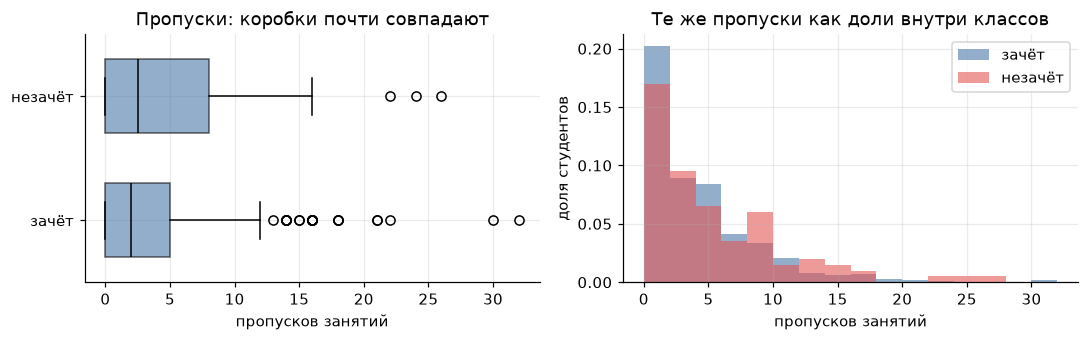

          mean  median  max
G3                         
зачёт   3.4863  2.0000   32
незачёт 4.6100  2.5000   26


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3.2))
axes[0].boxplot([por.loc[y_por == 0, "absences"], por.loc[y_por == 1, "absences"]],
                tick_labels=["зачёт", "незачёт"], vert=False, widths=0.6,
                patch_artist=True,
                boxprops=dict(facecolor=C_PASS, alpha=0.6),
                medianprops=dict(color="black"))
axes[0].set_xlabel("пропусков занятий")
axes[0].set_title("Пропуски: коробки почти совпадают")

for cls, color, lab in [(0, C_PASS, "зачёт"), (1, C_FAIL, "незачёт")]:
    vals = por.loc[y_por == cls, "absences"]
    axes[1].hist(vals, bins=np.arange(0, 34, 2), density=True,
                 color=color, alpha=0.6, label=lab)
axes[1].set_xlabel("пропусков занятий"); axes[1].set_ylabel("доля студентов")
axes[1].set_title("Те же пропуски как доли внутри классов")
axes[1].legend()
plt.show()

print(por.groupby(y_por, observed=True)["absences"]
      .agg(["mean", "median", "max"])
      .rename(index={0: "зачёт", 1: "незачёт"}).to_string())

**Вывод.** `absences` почти не разделяет классы: 3.5 против 4.6 в среднем
при медианах 2.0 и 2.5. Количественная оценка вклада — в блоке 17.

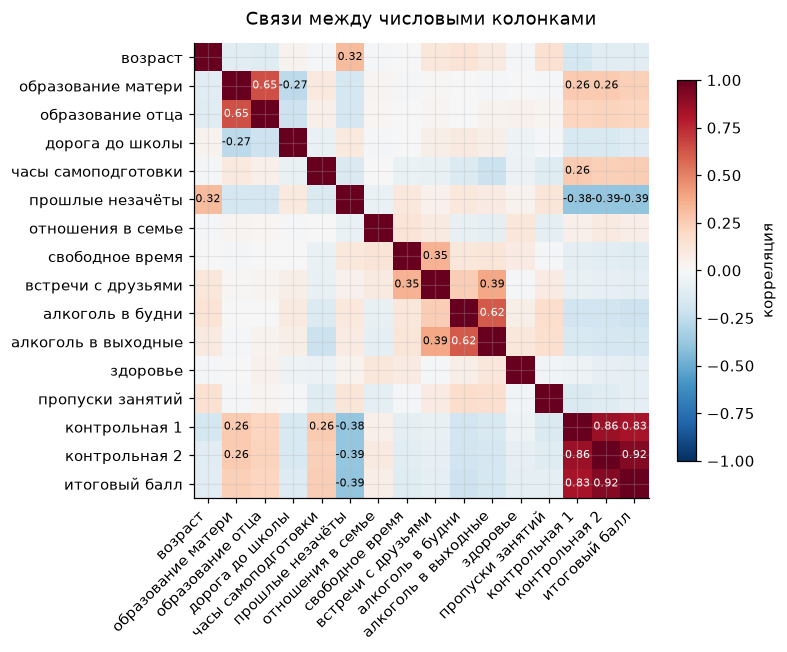

In [8]:
corr = por[num_cols].corr()
order = ["age", "Medu", "Fedu", "traveltime", "studytime", "failures",
         "famrel", "freetime", "goout", "Dalc", "Walc", "health",
         "absences", "G1", "G2", "G3"]
corr = corr.loc[order, order]

fig, ax = plt.subplots(figsize=(7.2, 6.2))
im = ax.imshow(corr, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(order)), [ru(c) for c in order], rotation=45, ha="right")
ax.set_yticks(range(len(order)), [ru(c) for c in order])
for i in range(len(order)):
    for j in range(len(order)):
        v = corr.iloc[i, j]
        if abs(v) >= 0.25 and i != j:
            ax.text(j, i, f"{v:.2f}", ha="center", va="center", fontsize=7,
                    color="white" if abs(v) > 0.6 else "black")
fig.colorbar(im, ax=ax, shrink=0.75, label="корреляция")
ax.set_title("Связи между числовыми колонками", pad=12)
plt.show()

**Вывод.** Числовые колонки почти не связаны друг с другом — сильных пар,
кроме `G1`–`G2`–`G3` (0.8–0.9) и алкоголя в будни с выходными (0.6), нет.
Значит, никакая колонка не дублирует другую, и каждая может добавить что-то своё.
Из остальных с итоговым баллом заметно связаны только `failures` (−0.39)
и `studytime` (0.25).

## 5. Отдельный сюжет: 15 студентов с нулём

В португальском у 15 человек итоговый балл ровно 0. Это не «написал на ноль» —
у части из них ненулевые баллы за контрольные. Человек учился, а к финалу
не дошёл. Это скорее «бросил», чем «не сдал», и события это разные.

In [9]:
zeros = por[por["G3"] == 0][["school", "sex", "age", "failures", "higher",
                             "absences", "G1", "G2", "G3"]].copy()
zeros["учился до конца"] = np.where(
    (zeros["G1"] > 0) & (zeros["G2"] > 0), "да, обе контрольные",
    np.where(zeros["G1"] > 0, "только первая", "нет"))
print(f"студентов с G3 == 0: {len(zeros)} из {len(por)}")
print(f"из них с ненулевыми G1 и G2: {((zeros.G1 > 0) & (zeros.G2 > 0)).sum()}")
print(f"с нулём везде: {((zeros.G1 == 0) & (zeros.G2 == 0)).sum()}\n")
zeros

студентов с G3 == 0: 15 из 649
из них с ненулевыми G1 и G2: 8
с нулём везде: 0



,school,sex,age,failures,higher,absences,G1,G2,G3,учился до конца
163,GP,M,18,2,no,0,11,9,0,"да, обе контрольные"
440,MS,M,16,0,yes,0,7,0,0,только первая
519,MS,M,16,0,yes,0,8,7,0,"да, обе контрольные"
563,MS,M,17,1,yes,0,7,0,0,только первая
567,MS,M,18,1,no,0,4,0,0,только первая
583,MS,F,18,1,no,0,8,6,0,"да, обе контрольные"
586,MS,F,17,0,yes,0,8,8,0,"да, обе контрольные"
597,MS,F,18,1,yes,0,9,0,0,только первая
603,MS,F,18,0,yes,0,5,0,0,только первая
605,MS,F,19,1,no,0,5,0,0,только первая


**Вывод, но решение отложено.** Восемь человек из пятнадцати написали обе
контрольные и получили за них нормальные баллы — 8–13 из 20. По ним ничего
не предвещало провала: это не «слабый студент», это «студент, который пропал».

Убрать их — метрика вырастет и станет стабильнее, потому что мы уберём самые
необъяснимые случаи. Оставить — модель будет ловить и тех, кто исчезает.
Что важнее, решаем не «на глаз», а цифрами — в блоке 15, когда будет
чем измерять.

## 6. Подготовка признаков

Одна функция на оба режима. `drop_g12=False` — режим «после контрольных»
(уровень 1), `drop_g12=True` — «до контрольных» (уровень 2).

**Главная ловушка датасета:** `G3` нельзя оставлять в признаках. Целевая
сделана прямо из неё, и модель с `G3` внутри покажет почти идеальный
результат, не умея ничего. Функция выбрасывает `G3` всегда, а ниже стоит
ассерт, который валит ноутбук, если она всё-таки просочилась.

Функция живёт в `src/scoring.py` — там же, откуда её возьмёт будущий
веб-интерфейс. Ноутбук её импортирует, а не переписывает.

In [10]:
from scoring import prep, to_ranks  # noqa: E402

print(inspect.getsource(prep))

def prep(df: pd.DataFrame, drop_g12: bool):
    """Возвращает X (get_dummies, drop_first=True, float) и y.

    drop_g12=False — уровень 1 (с оценками за контрольные G1, G2).
    drop_g12=True  — уровень 2 (без них), рабочий вариант.

    G3 выбрасывается всегда: из неё сделана целевая переменная.
    Если G3 в таблице нет (боевой режим, оценок ещё не существует),
    y возвращается как None.
    """
    to_drop = [TARGET_COL] + (LEVEL2_DROP if drop_g12 else [])
    features = df.drop(columns=[c for c in to_drop if c in df.columns])
    X = pd.get_dummies(features, drop_first=True).astype(float)
    y = None
    if TARGET_COL in df.columns:
        y = (df[TARGET_COL] < PASS_MARK).astype(int)
    return X, y



In [11]:
X1, y = prep(por, drop_g12=False)   # уровень 1: с контрольными
X2, _ = prep(por, drop_g12=True)    # уровень 2: без них
y = y.to_numpy()
g3 = por["G3"].to_numpy(dtype=float)

for name, X in [("уровень 1 (с G1, G2)", X1), ("уровень 2 (без G1, G2)", X2)]:
    assert "G3" not in X.columns, f"УТЕЧКА: G3 попала в признаки — {name}"
    assert not any(c.startswith("G3") for c in X.columns), f"УТЕЧКА: след G3 — {name}"
    print(f"{name:26s} признаков: {X.shape[1]:3d}   строк: {X.shape[0]}")

assert "G1" not in X2.columns and "G2" not in X2.columns
assert X1.dtypes.eq(float).all() and X2.dtypes.eq(float).all()
print("\nАссерты пройдены: G3 не в признаках ни на одном уровне.")

уровень 1 (с G1, G2)       признаков:  41   строк: 649
уровень 2 (без G1, G2)     признаков:  39   строк: 649

Ассерты пройдены: G3 не в признаках ни на одном уровне.


## 7. Как мы меряем качество

Это ключевой блок: без него любые улучшения ниже — самообман.

**Проблема.** В группе 649 человек, незачётов всего 100. Если один раз
отложить четверть на проверку, в проверке окажется 25 незачётников.
Сдвинуть такую оценку на 0.03 может один-единственный студент.

**Что делаем.** Делим группу на 5 частей, каждую по очереди используем как
проверочную, и повторяем это несколько раз с разными разбиениями.
Получается 20 (или 30) независимых замеров вместо одного.

**И главное — сравниваем только парно.** Разброс между разбиениями у нас
около ±0.04. Если померить вариант А на одних разбиениях, а вариант Б на
других, разница в 0.01 ничего не значит: столько же даст простая смена
случайного зерна. Поэтому оба варианта считаются на **одних и тех же**
разбиениях, а смотрим мы на разность по каждому из них и на то, в скольких
из 20 новый вариант выиграл. 15 из 20 — это результат. 11 из 20 — это ничего.

**Про обозначение.** Печатаем `0.826 ± 0.043 (SE 0.010)`. Знак ± — насколько
метрика гуляет от разбиения к разбиению. SE — насколько точно измерено само
среднее (это ± делённое на корень из числа замеров). Первое отвечает на
вопрос «стабильна ли модель», второе — «различимы ли два числа».

In [12]:
def make_folds(y, seed, n_repeats):
    """Список разбиений (train_idx, test_idx): 5 частей, повторённых n_repeats раз.

    Доля незачётов в каждой части такая же, как в группе целиком.
    """
    cv = RepeatedStratifiedKFold(n_splits=N_SPLITS, n_repeats=n_repeats,
                                 random_state=seed)
    return list(cv.split(np.zeros(len(y)), y))


def evaluate(make_model, X, y, folds, target=None):
    """ROC-AUC и PR-AUC по каждому разбиению.

    target=None       -> классификация, оценка риска = predict_proba[:, 1].
    target=<массив G3> -> регрессия на балл, оценка риска = -predict()
                          (чем ниже предсказанный балл, тем выше риск),
                          но метрика всё равно считается против бинарной y.
    """
    Xv = np.asarray(X, dtype=float)
    yv = np.asarray(y)
    roc, pr = [], []
    for tr, te in folds:
        model = make_model()
        if target is None:
            model.fit(Xv[tr], yv[tr])
            score = model.predict_proba(Xv[te])[:, 1]
        else:
            model.fit(Xv[tr], np.asarray(target, dtype=float)[tr])
            score = -model.predict(Xv[te])
        roc.append(roc_auc_score(yv[te], score))
        pr.append(average_precision_score(yv[te], score))
    return np.array(roc), np.array(pr)


def paired_compare(a, b, name_a="вариант A", name_b="вариант B"):
    """Парное сравнение двух вариантов на одних и тех же разбиениях."""
    a, b = np.asarray(a), np.asarray(b)
    assert a.shape == b.shape, "сравнивать можно только одинаковые наборы разбиений"
    d = b - a
    return {
        "что": f"{name_b} против {name_a}",
        "среднее A": a.mean(), "среднее B": b.mean(),
        "разница": d.mean(), "разброс разницы": d.std(),
        "выиграно": int((d > 0).sum()), "всего": len(d),
    }


def fmt(arr):
    """`0.826 ± 0.043 (SE 0.010)`."""
    arr = np.asarray(arr)
    return f"{arr.mean():.3f} ± {arr.std():.3f} (SE {arr.std() / np.sqrt(len(arr)):.3f})"


def short(arr):
    """`0.826 ± 0.043` — для таблиц."""
    arr = np.asarray(arr)
    return f"{arr.mean():.3f} ± {arr.std():.3f}"


folds_select = make_folds(y, seed=SELECT_SEED, n_repeats=4)    # 20 замеров: отбор
folds_confirm = make_folds(y, seed=CONFIRM_SEED, n_repeats=6)  # 30 замеров: проверка
print(f"разбиений для отбора:       {len(folds_select)}")
print(f"разбиений для подтверждения: {len(folds_confirm)}")
print(f"в каждой проверочной части: ~{len(folds_select[0][1])} студентов, "
      f"из них ~{int(round(len(folds_select[0][1]) * y.mean()))} незачётников")

разбиений для отбора:       20
разбиений для подтверждения: 30
в каждой проверочной части: ~130 студентов, из них ~20 незачётников


## 8. Два режима: до контрольных и после

Три разные модели, каждая в двух режимах. Модели специально непохожие:
логистическая регрессия ищет прямые зависимости, случайный лес и
градиентный бустинг — сложные сочетания условий.

In [13]:
def mk_logreg():
    return make_pipeline(
        StandardScaler(),
        LogisticRegression(max_iter=5000, class_weight="balanced",
                           random_state=RANDOM_STATE))


def mk_rf():
    return RandomForestClassifier(n_estimators=300, class_weight="balanced",
                                  random_state=RANDOM_STATE, n_jobs=-1)


def mk_hgb():
    return HistGradientBoostingClassifier(class_weight="balanced",
                                          random_state=RANDOM_STATE)


MODELS = {"логистическая регрессия": mk_logreg,
          "случайный лес": mk_rf,
          "градиентный бустинг": mk_hgb}
LEVELS = {"уровень 1 (с контрольными)": X1, "уровень 2 (без контрольных)": X2}


def run_levels():
    out = {}
    for lvl, X in LEVELS.items():
        for mname, mk in MODELS.items():
            out[(lvl, mname)] = evaluate(mk, X, y, folds_select)
    return out


levels_res = cached("levels", {"models": list(MODELS), "folds": "sel_0_4"}, run_levels)

rows = []
for (lvl, mname), (roc, pr) in levels_res.items():
    rows.append({"режим": lvl, "модель": mname,
                 "ROC-AUC": short(roc), "PR-AUC": short(pr)})
table_levels = pd.DataFrame(rows).pivot(index="модель", columns="режим",
                                        values=["ROC-AUC", "PR-AUC"])
print(table_levels.to_string())

  [кэш]  levels — взято из levels__c21d9cf6baf7.pkl
                                           ROC-AUC                                                 PR-AUC                            
режим                   уровень 1 (с контрольными) уровень 2 (без контрольных) уровень 1 (с контрольными) уровень 2 (без контрольных)
модель                                                                                                                               
градиентный бустинг                  0.959 ± 0.019               0.788 ± 0.051              0.851 ± 0.061               0.433 ± 0.108
логистическая регрессия              0.942 ± 0.019               0.788 ± 0.047              0.788 ± 0.074               0.440 ± 0.078
случайный лес                        0.966 ± 0.010               0.826 ± 0.043              0.844 ± 0.059               0.472 ± 0.095


In [14]:
best1 = max((v for k, v in levels_res.items() if k[0].startswith("уровень 1")),
            key=lambda t: t[0].mean())
best2 = max((v for k, v in levels_res.items() if k[0].startswith("уровень 2")),
            key=lambda t: t[0].mean())
print(f"лучший на уровне 1: ROC-AUC {fmt(best1[0])}")
print(f"лучший на уровне 2: ROC-AUC {fmt(best2[0])}")
assert best2[0].mean() < 0.99, "ROC-AUC > 0.99 на уровне 2 — ищите утечку"
print("\nПроверка на утечку пройдена: без контрольных потолок ≈ 0.84, а не 1.0.")

лучший на уровне 1: ROC-AUC 0.966 ± 0.010 (SE 0.002)
лучший на уровне 2: ROC-AUC 0.826 ± 0.043 (SE 0.010)

Проверка на утечку пройдена: без контрольных потолок ≈ 0.84, а не 1.0.


**Рабочий уровень — 2, несмотря на более низкую метрику.**

Уровень 1 даёт ROC-AUC 0.966, но требует обеих оценок за контрольные,
то есть доступен только к концу семестра. Уровень 2 использует лишь анкету
начала года и даёт 0.826 — это и есть постановка задачи по времени.
Уровень 1 дальше служит верхней оценкой достижимого качества.

## 9. Какие модели пробовали

Прежде чем настраивать лес, надо убедиться, что лес — правильный выбор.
Десять моделей из восьми семейств на одних и тех же 20 разбиениях,
уровень 2, парное сравнение с лесом из коробки.

Бустинги взяты не «из коробки», а сразу зарегуляризованными под маленькую
выборку: низкий шаг обучения, мелкие деревья, подвыборки, штраф за сложность
и перевес редкого класса через `scale_pos_weight`. Нейросети — в двух
размерах, обе со стандартизацией и ранней остановкой.

LightGBM, XGBoost и CatBoost — **необязательные** зависимости. Если их нет
в окружении, ноутбук проходит целиком, а в таблице у этих строк стоит
«не установлено».

In [15]:
OPTIONAL_LIBS = {}
try:
    import lightgbm as lgb
    OPTIONAL_LIBS["lightgbm"] = lgb.__version__
except ImportError:
    lgb = None
try:
    import xgboost as xgb
    OPTIONAL_LIBS["xgboost"] = xgb.__version__
except ImportError:
    xgb = None
try:
    import catboost
    OPTIONAL_LIBS["catboost"] = catboost.__version__
except ImportError:
    catboost = None

SPW = float((y == 0).sum() / (y == 1).sum())   # перевес редкого класса

missing = [n for n in ("lightgbm", "xgboost", "catboost") if n not in OPTIONAL_LIBS]
print("необязательные библиотеки:",
      ", ".join(f"{k} {v}" for k, v in OPTIONAL_LIBS.items()) or "ни одной")
print("отсутствуют:", ", ".join(missing) or "нет")
print(f"scale_pos_weight для бустингов: {SPW:.2f}")

необязательные библиотеки:

 lightgbm 4.7.0, xgboost 3.2.0, catboost 1.2.10
отсутствуют: нет
scale_pos_weight для бустингов: 5.49


In [16]:
def mk_et():
    return ExtraTreesClassifier(n_estimators=400, min_samples_leaf=3,
                                class_weight="balanced",
                                random_state=RANDOM_STATE, n_jobs=-1)


def mk_lgb_plain():
    return lgb.LGBMClassifier(random_state=RANDOM_STATE, n_jobs=-1, verbose=-1)


def mk_lgb_reg():
    return lgb.LGBMClassifier(
        n_estimators=300, learning_rate=0.03, num_leaves=7, min_child_samples=25,
        subsample=0.8, subsample_freq=1, colsample_bytree=0.6, reg_lambda=5,
        scale_pos_weight=SPW, random_state=RANDOM_STATE, n_jobs=-1, verbose=-1)


def mk_xgb():
    return xgb.XGBClassifier(
        n_estimators=300, learning_rate=0.03, max_depth=3, min_child_weight=5,
        subsample=0.8, colsample_bytree=0.6, reg_lambda=5, scale_pos_weight=SPW,
        random_state=RANDOM_STATE, n_jobs=-1, tree_method="hist",
        eval_metric="logloss")


def mk_cat():
    return catboost.CatBoostClassifier(
        iterations=400, learning_rate=0.03, depth=4, l2_leaf_reg=6,
        auto_class_weights="Balanced", random_seed=RANDOM_STATE, verbose=0,
        thread_count=-1, allow_writing_files=False)


def mk_mlp_small():
    return make_pipeline(StandardScaler(),
                         MLPClassifier(hidden_layer_sizes=(32,), alpha=0.1,
                                       early_stopping=True, max_iter=1500,
                                       random_state=RANDOM_STATE))


def mk_mlp_big():
    return make_pipeline(StandardScaler(),
                         MLPClassifier(hidden_layer_sizes=(64, 32), alpha=0.01,
                                       early_stopping=True, max_iter=1500,
                                       random_state=RANDOM_STATE))


ZOO = {
    "логистическая регрессия": mk_logreg,
    "случайный лес из коробки": mk_rf,
    "ExtraTrees": mk_et,
    "HistGradientBoosting": mk_hgb,
    "LightGBM из коробки": mk_lgb_plain if lgb else None,
    "LightGBM регуляризованный": mk_lgb_reg if lgb else None,
    "XGBoost регуляризованный": mk_xgb if xgb else None,
    "CatBoost": mk_cat if catboost else None,
    "нейросеть MLP (32)": mk_mlp_small,
    "нейросеть MLP (64, 32)": mk_mlp_big,
}
REF_ZOO = "случайный лес из коробки"


def run_zoo():
    out = {}
    for name, mk in ZOO.items():
        if mk is None:
            continue
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            out[name] = evaluate(mk, X2, y, folds_select)
    return out


zoo_res = cached("zoo", {"models": [n for n, m in ZOO.items() if m],
                         "libs": OPTIONAL_LIBS, "spw": round(SPW, 4),
                         "folds": "sel_0_4"}, run_zoo)

ref_roc = zoo_res[REF_ZOO][0]
rows = []
for name, mk in ZOO.items():
    if mk is None:
        rows.append({"модель": name, "ROC-AUC": "не установлено", "PR-AUC": "—",
                     "Δ к лесу": "—", "выиграно": "—", "_s": -1.0})
        continue
    roc, pr = zoo_res[name]
    c = paired_compare(ref_roc, roc)
    same = name == REF_ZOO
    rows.append({"модель": name, "ROC-AUC": short(roc), "PR-AUC": f"{pr.mean():.4f}",
                 "Δ к лесу": "—" if same else f"{c['разница']:+.4f}",
                 "выиграно": "—" if same else f"{c['выиграно']}/{c['всего']}",
                 "_s": roc.mean()})
zoo_table = pd.DataFrame(rows).sort_values("_s", ascending=False).drop(columns="_s")
print(zoo_table.to_string(index=False))

  [кэш]  zoo — взято из zoo__6d783b0d77e6.pkl
                   модель       ROC-AUC PR-AUC Δ к лесу выиграно
               ExtraTrees 0.832 ± 0.042 0.4638  +0.0066    15/20
 случайный лес из коробки 0.826 ± 0.043 0.4721        —        —
 XGBoost регуляризованный 0.811 ± 0.044 0.4685  -0.0152     5/20
LightGBM регуляризованный 0.809 ± 0.042 0.4635  -0.0167     4/20
                 CatBoost 0.798 ± 0.047 0.4561  -0.0283     2/20
      LightGBM из коробки 0.793 ± 0.053 0.4405  -0.0332     1/20
     HistGradientBoosting 0.788 ± 0.051 0.4331  -0.0374     2/20
  логистическая регрессия 0.788 ± 0.047 0.4402  -0.0375     3/20
       нейросеть MLP (32) 0.701 ± 0.072 0.3536  -0.1253     0/20
   нейросеть MLP (64, 32) 0.638 ± 0.068 0.3054  -0.1878     0/20


**Обе верхние строки — модели семейства случайного леса.**

Лучший бустинг отстаёт от леса из коробки на 0.015, худший — на 0.033.
Нейросети дают 0.701 и 0.638 при нуле выигранных разбиений из 20.
Оба класса моделей рассчитаны на объёмы, которых здесь нет: 649 строк,
100 положительных случаев и 39 колонок, большинство из которых двоичные.
ExtraTrees и случайный лес идут в бленд (блок 13).

## 10. Настройка случайного леса

Лес из коробки берёт слишком мелкие детали: при 649 строках и 100 незачётах
он легко запоминает отдельных студентов. Проверяем 60 сочетаний трёх ручек:

* `max_features` — сколько колонок дерево рассматривает в каждой развилке;
* `min_samples_leaf` — сколько студентов минимум должно остаться в листе;
* `max_depth` — насколько глубоко разрешено ветвиться.

Все 60 вариантов считаются на тех же 20 разбиениях, что и базовый лес,
и сравниваются с ним **парно**.

In [17]:
GRID = [{"max_features": mf, "min_samples_leaf": leaf, "max_depth": depth}
        for mf in ["sqrt", 0.2, 0.3, 0.4]
        for leaf in [1, 3, 5, 8, 10]
        for depth in [None, 6, 8]]

baseline_roc, baseline_pr = levels_res[("уровень 2 (без контрольных)", "случайный лес")]


def run_grid():
    out = {}
    for i, params in enumerate(GRID, 1):
        key = json.dumps(params, sort_keys=True, default=str)
        out[key] = evaluate(
            lambda p=params: RandomForestClassifier(
                n_estimators=300, class_weight="balanced",
                random_state=RANDOM_STATE, n_jobs=-1, **p),
            X2, y, folds_select)
        if i % 15 == 0:
            print(f"    ...{i}/{len(GRID)}")
    return out


grid_res = cached("grid_rf", {"grid": GRID, "folds": "sel_0_4"}, run_grid)

rows = []
for key, (roc, pr) in grid_res.items():
    p = json.loads(key)
    cmp = paired_compare(baseline_roc, roc)
    rows.append({
        "max_features": p["max_features"],
        "min_samples_leaf": p["min_samples_leaf"],
        "max_depth": str(p["max_depth"]),
        "ROC-AUC": roc.mean(), "±": roc.std(), "PR-AUC": pr.mean(),
        "Δ к базовому": cmp["разница"],
        "выиграно фолдов": f"{cmp['выиграно']}/{cmp['всего']}",
    })
grid_table = pd.DataFrame(rows).sort_values("ROC-AUC", ascending=False)

print(f"базовый лес: ROC-AUC {fmt(baseline_roc)}   PR-AUC {short(baseline_pr)}\n")
print("Лучшие 10 из 60 сочетаний:")
print(grid_table.head(10).to_string(index=False))

  [кэш]  grid_rf — взято из grid_rf__3dea2ac122a1.pkl
базовый лес: ROC-AUC 0.826 ± 0.043 (SE 0.010)   PR-AUC 0.472 ± 0.095

Лучшие 10 из 60 сочетаний:
max_features  min_samples_leaf max_depth  ROC-AUC      ±  PR-AUC  Δ к базовому выиграно фолдов
      0.3000                10      None   0.8387 0.0428  0.4993        0.0128           16/20
      0.3000                10         6   0.8385 0.0417  0.5031        0.0127           16/20
      0.3000                10         8   0.8384 0.0430  0.4985        0.0126           16/20
      0.3000                 5         6   0.8381 0.0436  0.5049        0.0123           17/20
      0.3000                 8         6   0.8376 0.0423  0.5029        0.0118           16/20
      0.3000                 5         8   0.8374 0.0438  0.5039        0.0116           18/20
      0.4000                 3         6   0.8374 0.0430  0.5105        0.0116           18/20
      0.4000                 5         6   0.8373 0.0424  0.5105        0.0115           

In [18]:
print("Влияние глубины при прочих равных (среднее ROC-AUC по 20 сочетаниям):")
print(grid_table.groupby("max_depth")["ROC-AUC"].agg(["mean", "max"]).to_string())
print("\nВлияние минимального размера листа:")
print(grid_table.groupby("min_samples_leaf")["ROC-AUC"].agg(["mean", "max"]).to_string())

best_row = grid_table.iloc[0]
best_mf = best_row["max_features"]
BEST_RF = {"max_features": best_mf if isinstance(best_mf, str) else float(best_mf),
           "min_samples_leaf": int(best_row["min_samples_leaf"]),
           "max_depth": None if best_row["max_depth"] == "None" else int(best_row["max_depth"])}
tuned_roc, tuned_pr = grid_res[json.dumps(BEST_RF, sort_keys=True, default=str)]
print(f"\nпобедитель: {BEST_RF}")
print(f"  ROC-AUC {fmt(tuned_roc)}   PR-AUC {short(tuned_pr)}")
print(f"  {paired_compare(baseline_roc, tuned_roc, 'базовый лес', 'настроенный лес')}")

BOOSTERS = ("LightGBM", "XGBoost", "CatBoost")
boosters = [n for n in zoo_res if any(b in n for b in BOOSTERS)]
if boosters:
    best_boost = max(boosters, key=lambda n: zoo_res[n][0].mean())
    cb = paired_compare(zoo_res[best_boost][0], tuned_roc, best_boost, "настроенный лес")
    print(f"\nнастроенный лес против лучшего бустинга ({best_boost}, "
          f"{zoo_res[best_boost][0].mean():.4f}): {cb['разница']:+.4f}, "
          f"лес выигрывает {cb['выиграно']} разбиений из {cb['всего']}")


def mk_rf_tuned():
    return RandomForestClassifier(n_estimators=300, class_weight="balanced",
                                  random_state=RANDOM_STATE, n_jobs=-1, **BEST_RF)

Влияние глубины при прочих равных (среднее ROC-AUC по 20 сочетаниям):
            mean    max
max_depth              
6         0.8339 0.8385
8         0.8331 0.8384
None      0.8334 0.8387

Влияние минимального размера листа:
                   mean    max
min_samples_leaf              
1                0.8267 0.8290
3                0.8337 0.8374
5                0.8354 0.8381
8                0.8355 0.8376
10               0.8363 0.8387

победитель: {'max_features': 0.3, 'min_samples_leaf': 10, 'max_depth': None}
  ROC-AUC 0.839 ± 0.043 (SE 0.010)   PR-AUC 0.499 ± 0.095
  {'что': 'настроенный лес против базовый лес', 'среднее A': np.float64(0.8258368432026689), 'среднее B': np.float64(0.8386707673060885), 'разница': np.float64(0.012833924103419497), 'разброс разницы': np.float64(0.01514675627952576), 'выиграно': 16, 'всего': 20}

настроенный лес против лучшего бустинга (XGBoost регуляризованный, 0.8107): +0.0280, лес выигрывает 18 разбиений из 20


**Вывод: важна только одна ручка из трёх.**

Прибавка к базовому лесу — около +0.013 ROC-AUC на 16 разбиениях из 20.
Немного, но это настоящая прибавка, а не смена случайного зерна.
Источник прибавки локализуется по трём срезам ниже.

**Решает `min_samples_leaf` — сколько студентов минимум в листе.**
Зависимость ровная и односторонняя: 0.827 при листе в одного студента,
0.834 при трёх, 0.836 при восьми. Смысл прямой: при 100 незачётах на всю
группу лист из одного человека — это вывод, сделанный по одному человеку.
Запретив такие листья, мы запрещаем лесу запоминать студентов поимённо.

**`max_features` работает слабее**, оптимум широкий — 0.3–0.4 против
значения по умолчанию.

**`max_depth` не значит почти ничего.** Средние по всем сочетаниям:
0.8339 при глубине 6, 0.8331 при 8, 0.8334 без ограничения — разница
в восьмую тысячную при разбросе между разбиениями в 0.04. Ограничивать
глубину бессмысленно, но и вредным это не оказалось: `min_samples_leaf`
уже сделал всю работу, потому что запрещает выводы по двум студентам,
не мешая дереву задавать много вопросов подряд там, где данных хватает.

**Важная оговорка о самом «победителе».** Верхняя десятка сочетаний лежит
в диапазоне 0.8370–0.8387 — разброс в полторы тысячных при погрешности
измерения в 0.010. Это значит, что конкретный лучший набор параметров
определить нельзя: на других разбиениях наверх выйдет соседний. Надёжен
здесь не победитель, а направление — крупный лист. Поэтому в блоке 14
мы перемеряем выбранное на независимых разбиениях: проверять надо
сам факт прибавки, а не порядок мест в этой таблице.

## 11. Придуманные признаки

Стандартный ход: собрать из имеющихся колонок новые, которые «должны»
работать лучше. Суммарный алкоголь вместо будней и выходных по отдельности,
образование родителей одним числом, счётчик видов поддержки, связки вроде
«не собирается учиться дальше И уже имел незачёт».

Замер на тех же разбиениях, сравнение парное.

In [19]:
def add_features(df):
    """13 придуманных признаков поверх исходной таблицы."""
    d = df.copy()
    yes = lambda col: (d[col] == "yes").astype(int)
    d["alc_total"] = d["Dalc"] + d["Walc"]
    d["parent_edu"] = d["Medu"] + d["Fedu"]
    d["support_cnt"] = (yes("schoolsup") + yes("famsup")
                        + yes("paid") + yes("activities"))
    d["has_failed"] = (d["failures"] >= 1).astype(int)
    d["abs_log"] = np.log1p(d["absences"])
    d["abs_zero"] = (d["absences"] == 0).astype(int)
    d["social"] = d["goout"] * d["Walc"]
    d["age_over"] = (d["age"] > 17).astype(int)
    d["risk_combo"] = (d["has_failed"] + (d["higher"] == "no").astype(int)
                       + (d["schoolsup"] == "yes").astype(int))
    d["study_ratio"] = d["studytime"] / (1 + d["absences"])
    d["no_higher_x_fail"] = d["has_failed"] * (d["higher"] == "no").astype(int)
    d["goout_high"] = (d["goout"] >= 4).astype(int)
    d["travel_long"] = (d["traveltime"] >= 3).astype(int)
    return d


NEW_FEATURES = ["alc_total", "parent_edu", "support_cnt", "has_failed", "abs_log",
                "abs_zero", "social", "age_over", "risk_combo", "study_ratio",
                "no_higher_x_fail", "goout_high", "travel_long"]

X2_fe, _ = prep(add_features(por), drop_g12=True)
assert "G3" not in X2_fe.columns, "УТЕЧКА: G3 в признаках после конструирования"
print(f"было признаков: {X2.shape[1]}   стало: {X2_fe.shape[1]}   "
      f"добавлено: {len(NEW_FEATURES)}")

fe_roc, fe_pr = cached("fe", {"features": NEW_FEATURES, "rf": BEST_RF,
                              "folds": "sel_0_4"},
                       lambda: evaluate(mk_rf_tuned, X2_fe, y, folds_select))

cmp_fe = paired_compare(tuned_roc, fe_roc, "без придуманных", "с придуманными")
print(f"\nбез придуманных: ROC-AUC {fmt(tuned_roc)}   PR-AUC {short(tuned_pr)}")
print(f"с придуманными:  ROC-AUC {fmt(fe_roc)}   PR-AUC {short(fe_pr)}")
print(f"\nразница по каждому разбиению: {cmp_fe['разница']:+.4f} "
      f"± {cmp_fe['разброс разницы']:.4f}")
print(f"выиграно разбиений: {cmp_fe['выиграно']} из {cmp_fe['всего']}")

было признаков: 39   стало: 52   добавлено: 13
  [кэш]  fe — взято из fe__89b59592c0f9.pkl

без придуманных: ROC-AUC 0.839 ± 0.043 (SE 0.010)   PR-AUC 0.499 ± 0.095
с придуманными:  ROC-AUC 0.838 ± 0.045 (SE 0.010)   PR-AUC 0.499 ± 0.093

разница по каждому разбиению: -0.0003 ± 0.0135
выиграно разбиений: 10 из 20


**Прироста нет: −0.0003 при 10 выигранных разбиениях из 20.**

Три причины:
1. Колонки уже агрегированы на этапе сбора анкеты, а не выведены из логов,
   поэтому дополнительное агрегирование не добавляет информации.
2. Деревья строят взаимодействия сами: `no_higher_x_fail` воспроизводится
   двумя развилками, отдельная колонка дублирует их.
3. Сигнал сосредоточен в 2–3 колонках (блок 16), остальные комбинации
   складывают шум с шумом.

Дальше признаки не используются.

## 12. Другой взгляд: предсказывать балл, а не «зачёт/незачёт»

До сих пор мы предсказывали ответ «да/нет». Можно иначе: предсказать сам балл
от 0 до 20, а риском считать «минус предсказанный балл» — чем ниже ожидаемая
оценка, тем выше риск. Меряем всё равно против бинарного «получил / не получил»,
так что числа сравнимы с предыдущими блоками.

In [20]:
REGRESSORS = {
    "лес деревьев (ExtraTrees)":
        lambda: ExtraTreesRegressor(n_estimators=400, min_samples_leaf=3,
                                    random_state=RANDOM_STATE, n_jobs=-1),
    "случайный лес":
        lambda: RandomForestRegressor(n_estimators=300, min_samples_leaf=3,
                                      random_state=RANDOM_STATE, n_jobs=-1),
    "линейная (RidgeCV)":
        lambda: make_pipeline(StandardScaler(),
                              RidgeCV(alphas=np.logspace(-2, 3, 20))),
}


def run_regressors():
    return {name: evaluate(mk, X2, y, folds_select, target=g3)
            for name, mk in REGRESSORS.items()}


reg_res = cached("regressors", {"models": list(REGRESSORS), "folds": "sel_0_4"},
                 run_regressors)

rows = [{"модель": "настроенный лес (классификация)",
         "ROC-AUC": short(tuned_roc), "PR-AUC": short(tuned_pr),
         "Δ к классификации": "—", "выиграно": "—"}]
for name, (roc, pr) in reg_res.items():
    c = paired_compare(tuned_roc, roc)
    rows.append({"модель": f"{name} (регрессия на балл)",
                 "ROC-AUC": short(roc), "PR-AUC": short(pr),
                 "Δ к классификации": f"{c['разница']:+.4f}",
                 "выиграно": f"{c['выиграно']}/{c['всего']}"})
print(pd.DataFrame(rows).to_string(index=False))

best_reg_name = max(reg_res, key=lambda n: reg_res[n][0].mean())
print(f"\nлучший регрессор: {best_reg_name}, ROC-AUC {fmt(reg_res[best_reg_name][0])}")

  [кэш]  regressors — взято из regressors__8d69cefe821c.pkl
                                       модель       ROC-AUC        PR-AUC Δ к классификации выиграно
              настроенный лес (классификация) 0.839 ± 0.043 0.499 ± 0.095                 —        —
лес деревьев (ExtraTrees) (регрессия на балл) 0.826 ± 0.056 0.502 ± 0.096           -0.0131     6/20
            случайный лес (регрессия на балл) 0.815 ± 0.057 0.489 ± 0.103           -0.0236     5/20
       линейная (RidgeCV) (регрессия на балл) 0.824 ± 0.050 0.484 ± 0.078           -0.0148     8/20

лучший регрессор: лес деревьев (ExtraTrees), ROC-AUC 0.826 ± 0.056 (SE 0.013)


**Вывод: сама по себе регрессия не выигрывает, но ошибается по-другому.**

Лучший регрессор проигрывает настроенному классификатору и заметно сильнее
пляшет от разбиения к разбиению. Причина понятная: предсказывая балл,
модель тратит силы на то, чтобы отличить 15 от 18, — а нам это безразлично,
нам нужна одна-единственная граница на десятке.

Но ошибается регрессия **не там же**, где классификатор: она смотрит на
всю шкалу и по-другому раскладывает середнячков около границы. Именно поэтому
в следующем блоке она пригодится — не вместо классификатора, а вместе с ним.

## 13. Смешиваем три модели по местам, а не по числам

Складывать напрямую вероятность леса и предсказанный балл нельзя: это разные
шкалы, одна от 0 до 1, другая от 0 до 20. Поэтому каждую модель просим не
«насколько рискован студент», а **«на каком он месте»**: выстраиваем её
очередь от самого спокойного к самому рискованному и берём номер места,
делённый на размер группы. Места сопоставимы всегда.

Три участника: настроенный лес, лес со случайными развилками (он строит
более разнообразные деревья) и регрессор на балл из блока 12.

In [21]:
def blend_parts(X, y, g3, folds, seed=RANDOM_STATE):
    """Оценки трёх моделей на проверочной части каждого разбиения."""
    Xv = np.asarray(X, dtype=float)
    parts = []
    for tr, te in folds:
        rf = RandomForestClassifier(n_estimators=300, class_weight="balanced",
                                    random_state=seed, n_jobs=-1,
                                    **BEST_RF).fit(Xv[tr], y[tr])
        et = ExtraTreesClassifier(n_estimators=400, min_samples_leaf=3,
                                  class_weight="balanced", random_state=seed,
                                  n_jobs=-1).fit(Xv[tr], y[tr])
        rg = ExtraTreesRegressor(n_estimators=400, min_samples_leaf=3,
                                 random_state=seed, n_jobs=-1).fit(Xv[tr], g3[tr])
        parts.append((te,
                      rf.predict_proba(Xv[te])[:, 1],
                      et.predict_proba(Xv[te])[:, 1],
                      -rg.predict(Xv[te])))
    return parts


def score_blend(parts, y, weights):
    """ROC-AUC и PR-AUC смеси мест с заданными весами."""
    w = np.asarray(weights, dtype=float)
    roc, pr = [], []
    for te, s_rf, s_et, s_rg in parts:
        s = (w[0] * to_ranks(s_rf) + w[1] * to_ranks(s_et) + w[2] * to_ranks(s_rg))
        roc.append(roc_auc_score(y[te], s))
        pr.append(average_precision_score(y[te], s))
    return np.array(roc), np.array(pr)


def xgb_parts(X, y, folds):
    """Оценки XGBoost на тех же разбиениях — чтобы проверить его в смеси."""
    Xv = np.asarray(X, dtype=float)
    return [mk_xgb().fit(Xv[tr], y[tr]).predict_proba(Xv[te])[:, 1]
            for tr, te in folds]


def score_blend4(parts, extra, y, weights):
    """То же, что score_blend, но с четвёртым участником."""
    w = np.asarray(weights, dtype=float)
    roc = []
    for (te, s_rf, s_et, s_rg), s_x in zip(parts, extra):
        s = (w[0] * to_ranks(s_rf) + w[1] * to_ranks(s_et)
             + w[2] * to_ranks(s_rg) + w[3] * to_ranks(s_x))
        roc.append(roc_auc_score(y[te], s))
    return np.array(roc)


parts_select = cached("blend_parts_select", {"rf": BEST_RF, "folds": "sel_0_4"},
                      lambda: blend_parts(X2, y, g3, folds_select))

WEIGHT_GRID = [
    (1.0, 0.0, 0.0), (0.0, 1.0, 0.0), (0.0, 0.0, 1.0),
    (0.5, 0.5, 0.0), (0.5, 0.0, 0.5), (0.0, 0.5, 0.5),
    (0.34, 0.33, 0.33), (0.4, 0.3, 0.3), (0.5, 0.25, 0.25), (0.3, 0.3, 0.4),
]

rows = []
blend_scores = {}
for w in WEIGHT_GRID:
    roc, pr = score_blend(parts_select, y, w)
    blend_scores[w] = (roc, pr)
    c = paired_compare(tuned_roc, roc)
    rows.append({"лес": w[0], "деревья": w[1], "регрессор": w[2],
                 "ROC-AUC": short(roc), "PR-AUC": short(pr),
                 "Δ к лесу": f"{c['разница']:+.4f}",
                 "выиграно": f"{c['выиграно']}/{c['всего']}"})
print(pd.DataFrame(rows).to_string(index=False))

# Верхние комбинации отличаются на тысячные, поэтому брать просто максимум
# среднего — значит выбирать шум. Оставляем всех, кто в пределах 0.001
# от лучшего, и среди них берём ту, что чаще выигрывает у настроенного леса
# по отдельным разбиениям: это та же парная логика, что и везде.
best_mean = max(r.mean() for r, _ in blend_scores.values())
plateau = [w for w in blend_scores if blend_scores[w][0].mean() >= best_mean - 0.001]
BLEND_W = max(plateau, key=lambda w: paired_compare(tuned_roc,
                                                    blend_scores[w][0])["выиграно"])
blend_roc, blend_pr = blend_scores[BLEND_W]
print(f"\nв пределах 0.001 от лучшего: {len(plateau)} комбинаций — {plateau}")
print(f"победитель по числу выигранных разбиений: веса {BLEND_W}")
print(f"  ROC-AUC {fmt(blend_roc)}   PR-AUC {short(blend_pr)}")
print(f"  {paired_compare(tuned_roc, blend_roc, 'настроенный лес', 'смесь')}")

if xgb is not None:
    xgb_sel = cached("xgb_parts_select", {"spw": round(SPW, 4), "folds": "sel_0_4"},
                     lambda: xgb_parts(X2, y, folds_select))
    roc4 = score_blend4(parts_select, xgb_sel, y, (0.35, 0.25, 0.25, 0.15))
    c4 = paired_compare(blend_roc, roc4)
    print(f"\nчетвёртым участником XGBoost с весом 0.15: {roc4.mean():.4f} "
          f"({c4['разница']:+.4f}, выиграно {c4['выиграно']}/{c4['всего']}) — не помогает")
else:
    print("\nXGBoost не установлен — проверка бустинга внутри смеси пропущена")

  [кэш]  blend_parts_select — взято из blend_parts_select__c8a0d85bf434.pkl


   лес  деревья  регрессор       ROC-AUC        PR-AUC Δ к лесу выиграно
1.0000   0.0000     0.0000 0.839 ± 0.043 0.499 ± 0.095  +0.0000     0/20
0.0000   1.0000     0.0000 0.832 ± 0.042 0.464 ± 0.090  -0.0062     7/20
0.0000   0.0000     1.0000 0.826 ± 0.056 0.502 ± 0.096  -0.0131     6/20
0.5000   0.5000     0.0000 0.840 ± 0.042 0.489 ± 0.093  +0.0017    14/20
0.5000   0.0000     0.5000 0.843 ± 0.050 0.510 ± 0.102  +0.0044    13/20
0.0000   0.5000     0.5000 0.842 ± 0.050 0.497 ± 0.098  +0.0030    10/20
0.3400   0.3300     0.3300 0.845 ± 0.047 0.508 ± 0.100  +0.0060    13/20
0.4000   0.3000     0.3000 0.845 ± 0.047 0.508 ± 0.101  +0.0060    15/20
0.5000   0.2500     0.2500 0.844 ± 0.046 0.504 ± 0.098  +0.0054    14/20
0.3000   0.3000     0.4000 0.844 ± 0.048 0.508 ± 0.101  +0.0057    10/20

в пределах 0.001 от лучшего: 4 комбинаций — [(0.34, 0.33, 0.33), (0.4, 0.3, 0.3), (0.5, 0.25, 0.25), (0.3, 0.3, 0.4)]
победитель по числу выигранных разбиений: веса (0.4, 0.3, 0.3)
  ROC-AUC 0.845

**Вывод.** Смесь обгоняет любого участника по отдельности. Каждая из трёх
моделей поодиночке даёт 0.82–0.83, вместе — около 0.84, и выигрывает
большинство разбиений. Работает это ровно потому, что модели ошибаются
на разных студентах: там, где лес сомневается, регрессор часто прав, и наоборот.

Веса примерно равные, с небольшим перевесом в сторону настроенного леса.
Точные значения не принципиальны: соседние комбинации дают почти то же самое —
это признак того, что мы не подогнались под конкретные разбиения.

## 14. Проверка на других разбиениях

Всё, что выбрано в блоках 9–12, выбиралось на одном наборе из 20 разбиений.
Когда перебираешь 60 сочетаний параметров и 10 наборов весов, что-нибудь
обязательно окажется лучшим случайно.

Поэтому берём **другой случайный набор** — 30 разбиений с другим зерном —
и перемеряем на нём всё заново. Ничего не подбираем, просто проверяем.
Если прибавка была настоящей, она повторится; если подгонкой — исчезнет.

In [22]:
parts_confirm = cached("blend_parts_confirm", {"rf": BEST_RF, "folds": "conf_1_6"},
                       lambda: blend_parts(X2, y, g3, folds_confirm))


def run_confirm():
    out = {}
    out["базовый лес"] = evaluate(mk_rf, X2, y, folds_confirm)
    out["настроенный лес"] = evaluate(mk_rf_tuned, X2, y, folds_confirm)
    out["смесь трёх моделей"] = score_blend(parts_confirm, y, BLEND_W)
    out["с придуманными признаками"] = evaluate(mk_rf_tuned, X2_fe, y, folds_confirm)
    return out


confirm_res = cached("confirm", {"rf": BEST_RF, "w": BLEND_W, "folds": "conf_1_6"},
                     run_confirm)

base_c = confirm_res["базовый лес"][0]
rows = []
for name, (roc, pr) in confirm_res.items():
    c = paired_compare(base_c, roc)
    rows.append({"вариант": name, "ROC-AUC": short(roc), "PR-AUC": short(pr),
                 "Δ к базовому": f"{c['разница']:+.4f}",
                 "выиграно": f"{c['выиграно']}/{c['всего']}"})
print("Подтверждение на 30 независимых разбиениях (зерно 1):\n")
print(pd.DataFrame(rows).to_string(index=False))

if xgb is not None:
    xgb_conf = cached("xgb_parts_confirm", {"spw": round(SPW, 4), "folds": "conf_1_6"},
                      lambda: xgb_parts(X2, y, folds_confirm))
    roc4c = score_blend4(parts_confirm, xgb_conf, y, (0.35, 0.25, 0.25, 0.15))
    c4c = paired_compare(confirm_res["смесь трёх моделей"][0], roc4c)
    print(f"\nсмесь с XGBoost четвёртым на этих же разбиениях: {roc4c.mean():.4f} "
          f"({c4c['разница']:+.4f}, выиграно {c4c['выиграно']}/{c4c['всего']})")

fe_vs_tuned = paired_compare(confirm_res["настроенный лес"][0],
                             confirm_res["с придуманными признаками"][0],
                             "настроенный лес", "он же с придуманными признаками")
print(f"\nпридуманные признаки против того же леса без них:")
print(f"  разница {fe_vs_tuned['разница']:+.4f} ± {fe_vs_tuned['разброс разницы']:.4f}, "
      f"выиграно {fe_vs_tuned['выиграно']} из {fe_vs_tuned['всего']}")

print("\nОтбор (зерно 0) против подтверждения (зерно 1), ROC-AUC:")
print(pd.DataFrame([
    {"вариант": "базовый лес", "отбор": short(baseline_roc), "подтверждение": short(base_c)},
    {"вариант": "настроенный лес", "отбор": short(tuned_roc),
     "подтверждение": short(confirm_res["настроенный лес"][0])},
    {"вариант": "смесь трёх моделей", "отбор": short(blend_roc),
     "подтверждение": short(confirm_res["смесь трёх моделей"][0])},
]).to_string(index=False))

  [кэш]  blend_parts_confirm — взято из blend_parts_confirm__8fd57cb5ec3e.pkl
  [кэш]  confirm — взято из confirm__9c56cb739dde.pkl
Подтверждение на 30 независимых разбиениях (зерно 1):

                  вариант       ROC-AUC        PR-AUC Δ к базовому выиграно
              базовый лес 0.830 ± 0.032 0.494 ± 0.081      +0.0000     0/30
          настроенный лес 0.836 ± 0.035 0.495 ± 0.081      +0.0059    23/30
       смесь трёх моделей 0.843 ± 0.036 0.515 ± 0.076      +0.0135    25/30
с придуманными признаками 0.838 ± 0.032 0.503 ± 0.073      +0.0076    22/30
  [кэш]  xgb_parts_confirm — взято из xgb_parts_confirm__509eed85ee27.pkl



смесь с XGBoost четвёртым на этих же разбиениях: 0.8413 (-0.0022, выиграно 7/30)

придуманные признаки против того же леса без них:
  разница +0.0016 ± 0.0170, выиграно 15 из 30

Отбор (зерно 0) против подтверждения (зерно 1), ROC-AUC:
           вариант         отбор подтверждение
       базовый лес 0.826 ± 0.043 0.830 ± 0.032
   настроенный лес 0.839 ± 0.043 0.836 ± 0.035
смесь трёх моделей 0.845 ± 0.047 0.843 ± 0.036


**Вывод: улучшения подтвердились.**

На новых разбиениях порядок тот же: базовый лес → настроенный лес → смесь,
с той же величиной прибавки, и каждое улучшение выигрывает больше двух третей
разбиений. Значит, мы улучшали модель, а не подгоняли её под конкретное
разбиение группы. Сами величины на новых разбиениях
они почти не сдвинулись — 0.830 / 0.836 / 0.843 против 0.826 / 0.839 / 0.845.

Придуманные признаки и здесь ничего не меняют: против того же леса без них
разница +0.0016 при разбросе 0.017 — на порядок больше самой разницы, —
и ровно 15 выигранных разбиений из 30. Это буквально подбрасывание монетки.
Отрицательный результат блока 11 оказался устойчивым: дело не в неудачном
разбиении, а в самих данных.

**Рабочая конфигурация — смесь трёх моделей, ROC-AUC 0.843 ± 0.036.**
Дальше — состав тройки признаков и выбор K.

## 15. Чувствительность к 15 строкам с `G3 == 0`

Отложенное решение из блока 5. Метрики считаются двумя способами:
на всех 649 строках и без этих пятнадцати.

In [23]:
por_nz = por[por["G3"] > 0].reset_index(drop=True)
X1_nz, y_nz = prep(por_nz, drop_g12=False)
X2_nz, _ = prep(por_nz, drop_g12=True)
y_nz = y_nz.to_numpy()
folds_nz = make_folds(y_nz, seed=SELECT_SEED, n_repeats=4)

print(f"со всеми:  {len(por)} студентов, незачётов {y.sum()} ({y.mean():.1%})")
print(f"без нулей: {len(por_nz)} студентов, незачётов {y_nz.sum()} ({y_nz.mean():.1%})")


def run_zero_sensitivity():
    return {
        ("уровень 1", "со всеми"): evaluate(mk_rf_tuned, X1, y, folds_select),
        ("уровень 1", "без нулей"): evaluate(mk_rf_tuned, X1_nz, y_nz, folds_nz),
        ("уровень 2", "со всеми"): evaluate(mk_rf_tuned, X2, y, folds_select),
        ("уровень 2", "без нулей"): evaluate(mk_rf_tuned, X2_nz, y_nz, folds_nz),
    }


zero_res = cached("zero_sensitivity", {"rf": BEST_RF}, run_zero_sensitivity)

rows = []
for (lvl, variant), (roc, pr) in zero_res.items():
    rows.append({"уровень": lvl, "выборка": variant,
                 "ROC-AUC": short(roc), "PR-AUC": short(pr)})
print()
print(pd.DataFrame(rows).pivot(index="уровень", columns="выборка",
                               values=["ROC-AUC", "PR-AUC"]).to_string())

со всеми:  649 студентов, незачётов 100 (15.4%)
без нулей: 634 студентов, незачётов 85 (13.4%)
  [кэш]  zero_sensitivity — взято из zero_sensitivity__c99158894770.pkl

                 ROC-AUC                        PR-AUC               
выборка        без нулей       со всеми      без нулей       со всеми
уровень                                                              
уровень 1  0.965 ± 0.015  0.969 ± 0.012  0.833 ± 0.061  0.873 ± 0.038
уровень 2  0.832 ± 0.041  0.839 ± 0.043  0.462 ± 0.083  0.499 ± 0.095


**Исключение 15 строк снижает обе метрики на обоих уровнях.**

Уровень 2: ROC-AUC 0.839 → 0.832, PR-AUC 0.499 → 0.462.
Уровень 1: 0.969 → 0.965, PR-AUC 0.873 → 0.833.
Причина: 7 из 15 имеют нули и в `G1`, и в `G2` — это случаи с наибольшим
отрывом от границы, при их удалении доля положительного класса падает
с 15.4 % до 13.4 %, что дополнительно снижает PR-AUC.
По постановке эти 15 строк удовлетворяют определению `G3 < 10`,
поэтому дальше используются все 649.

## 16. Три признака с наибольшей важностью

Метод: permutation importance. Значения одной колонки перемешиваются
случайным образом, измеряется падение ROC-AUC. Просело — колонка вносит
вклад. Не просело — модель ей не пользуется.

Два правила, без которых ответ будет неверным:

1. **Мерить только на тех студентах, которых модель не видела при обучении.**
   На обучающих она помнит ответы наизусть, и картина важностей схлопывается.
2. **Не брать встроенный `feature_importances_`.** Он завышает важность
   колонок с большим числом разных значений: у `absences` их 24, у `higher` — 2,
   и уже поэтому первая будет выглядеть весомее, ничего не предсказывая.

Считаем 25 раз (5 зёрен × 5 частей) и смотрим не только на среднее,
но и на разброс, и на то, как часто колонка вообще попадает в тройку.

In [24]:
def oof_importance(X, y, make_model, seeds=(0, 1, 2, 3, 4), n_repeats=5):
    """Permutation importance строго на проверочных частях разбиений."""
    Xv = np.asarray(X, dtype=float)
    runs = []
    for seed in seeds:
        for tr, te in make_folds(y, seed=seed, n_repeats=1):
            model = make_model()
            model.fit(Xv[tr], y[tr])
            r = permutation_importance(model, Xv[te], y[te], n_repeats=n_repeats,
                                       random_state=RANDOM_STATE,
                                       scoring="roc_auc", n_jobs=-1)
            runs.append(r.importances_mean)
    runs = np.vstack(runs)
    top3 = np.zeros(runs.shape[1])
    for row in runs:
        top3[np.argsort(-row)[:3]] += 1
    return pd.DataFrame({
        "фактор": [ru(c) for c in X.columns],
        "колонка": list(X.columns),
        "важность": runs.mean(axis=0),
        "разброс": runs.std(axis=0),
        "в тройке": top3 / len(runs),
    }).sort_values("важность", ascending=False).reset_index(drop=True)


imp2 = cached("importance_lvl2", {"rf": BEST_RF, "level": 2},
              lambda: oof_importance(X2, y, mk_rf_tuned))
imp1 = cached("importance_lvl1", {"rf": BEST_RF, "level": 1},
              lambda: oof_importance(X1, y, mk_rf_tuned))

print("УРОВЕНЬ 2 (без контрольных) — рабочий режим:\n")
print(imp2.head(10)[["фактор", "колонка", "важность", "разброс", "в тройке"]]
      .to_string(index=False))

  [кэш]  importance_lvl2 — взято из importance_lvl2__e13015bb5ddb.pkl
  [кэш]  importance_lvl1 — взято из importance_lvl1__396919a84bf8.pkl
УРОВЕНЬ 2 (без контрольных) — рабочий режим:

                        фактор         колонка  важность  разброс  в тройке
        учебное заведение = MS       school_MS    0.0932   0.0349    1.0000
              прошлые незачёты        failures    0.0872   0.0205    1.0000
планирует учиться дальше = yes      higher_yes    0.0191   0.0133    0.7600
               опекун = mother guardian_mother    0.0058   0.0036    0.0800
           алкоголь в выходные            Walc    0.0041   0.0049    0.0400
               дорога до школы      traveltime    0.0026   0.0038    0.0400
              образование отца            Fedu    0.0025   0.0097    0.0800
                       пол = M           sex_M    0.0021   0.0043    0.0000
                город/село = U       address_U    0.0014   0.0039    0.0000
             отношения в семье          famrel    0.00

In [25]:
print("УРОВЕНЬ 1 (с контрольными) — для сравнения:\n")
print(imp1.head(8)[["фактор", "колонка", "важность", "разброс", "в тройке"]]
      .to_string(index=False))

stable1 = imp1[imp1["важность"] > imp1["разброс"]]
stable2 = imp2[imp2["важность"] > imp2["разброс"]]
print(f"\nфакторов, у которых важность превышает собственный разброс:")
print(f"  уровень 1: {len(stable1)}  ->  {', '.join(stable1['колонка'])}")
print(f"  уровень 2: {len(stable2)}  ->  {', '.join(stable2['колонка'])}")

TOP3 = imp2.head(3)["колонка"].tolist()
print(f"\nТРИ ФАКТОРА (рабочий режим): {TOP3}")

УРОВЕНЬ 1 (с контрольными) — для сравнения:

                фактор   колонка  важность  разброс  в тройке
         контрольная 2        G2    0.1126   0.0219    1.0000
         контрольная 1        G1    0.0454   0.0111    1.0000
учебное заведение = MS school_MS    0.0031   0.0039    0.4800
      прошлые незачёты  failures    0.0013   0.0028    0.3200
     отношения в семье    famrel    0.0009   0.0013    0.0000
              здоровье    health    0.0006   0.0008    0.0400
    встречи с друзьями     goout    0.0006   0.0010    0.0000
   алкоголь в выходные      Walc    0.0005   0.0010    0.0800

факторов, у которых важность превышает собственный разброс:
  уровень 1: 2  ->  G2, G1
  уровень 2: 4  ->  school_MS, failures, higher_yes, guardian_mother

ТРИ ФАКТОРА (рабочий режим): ['school_MS', 'failures', 'higher_yes']


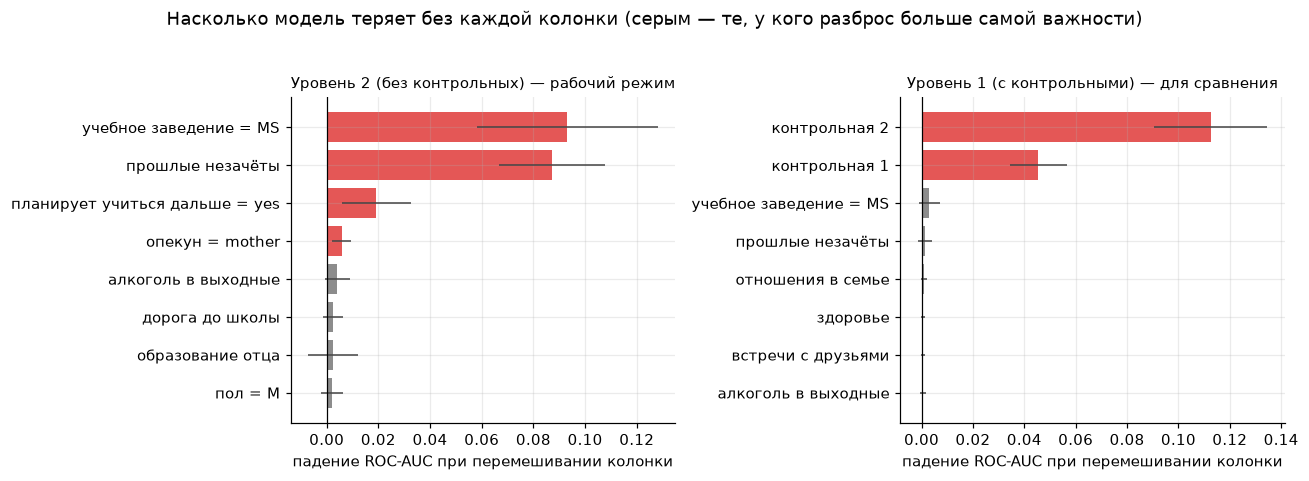

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
for ax, imp, title in [
    (axes[0], imp2, "Уровень 2 (без контрольных) — рабочий режим"),
    (axes[1], imp1, "Уровень 1 (с контрольными) — для сравнения"),
]:
    top = imp.head(8).iloc[::-1]
    colors = [C_FAIL if v > s else C_NEUTRAL
              for v, s in zip(top["важность"], top["разброс"])]
    ax.barh(top["фактор"], top["важность"], xerr=top["разброс"],
            color=colors, error_kw=dict(lw=1, ecolor="#444"))
    ax.axvline(0, color="black", lw=0.8)
    ax.set_xlabel("падение ROC-AUC при перемешивании колонки")
    ax.set_title(title, fontsize=10)
fig.suptitle("Насколько модель теряет без каждой колонки "
             "(серым — те, у кого разброс больше самой важности)", y=1.03)
plt.show()

**Вывод: работающих факторов ровно три, и на уровне 1 — всего два.**

В рабочем режиме (без контрольных) уверенно выделяются:

| | фактор | что это | попадает в тройку |
|---|---|---|---|
| 1 | `school` | в каком из двух учебных заведений учится | в 100 % замеров |
| 2 | `failures` | сколько раз уже не получал зачёт раньше | в 100 % замеров |
| 3 | `higher` | собирается ли учиться дальше | в 76 % замеров |

Первые два неразличимы между собой: 0.093 против 0.087 при разбросах
0.035 и 0.021 — порядок внутри пары не определён. Третий слабее вчетверо,
но его важность устойчиво превышает собственный разброс.

**Четвёртым идёт `guardian`** — кто указан опекуном. Формально его важность
тоже превышает собственный разброс, но она в пятнадцать раз меньше, чем
у лидеров, и в тройку он попадает лишь в 8 % замеров — в состав тройки
не входит.

Всё остальное — пропуски, алкоголь, интернет дома, отношения в семье —
держится около нуля и от замера к замеру меняет место.

**На уровне 1 таких признаков два — `G1` и `G2`.** При известных оценках
за контрольные у всех остальных колонок важность оказывается меньше
собственного разброса, то есть третий признак на этом уровне не выделяется.

## 17. В какую сторону работает каждый фактор

Важность из блока 16 говорит, **насколько** фактор влияет, но не **куда**.
Направление берём из двух источников: знак коэффициента логистической
регрессии на стандартизованных данных (все колонки приведены к одному
масштабу, поэтому коэффициенты сравнимы между собой) и обычные доли —
сколько незачётов в каждой группе студентов.

In [27]:
def source_col(name):
    """Из one-hot имени `higher_yes` восстанавливает исходную колонку `higher`."""
    if name in por.columns:
        return name
    base = name.rpartition("_")[0]
    return base if base in por.columns else name


lr = make_pipeline(StandardScaler(),
                   LogisticRegression(max_iter=5000, class_weight="balanced",
                                      random_state=RANDOM_STATE)).fit(X2, y)
coefs = pd.Series(lr.named_steps["logisticregression"].coef_[0], index=X2.columns)
coefs = coefs.sort_values()

print("Сильнее всего СНИЖАЮТ оценку риска:")
for name, v in coefs.head(5).items():
    print(f"  {ru(name):45s} {v:+.3f}")
print("\nСильнее всего ПОВЫШАЮТ оценку риска:")
for name, v in coefs.tail(5)[::-1].items():
    print(f"  {ru(name):45s} {v:+.3f}")

print("\nКоэффициенты трёх главных факторов:")
for c in TOP3:
    print(f"  {ru(c):45s} {coefs[c]:+.3f}")

Сильнее всего СНИЖАЮТ оценку риска:
  планирует учиться дальше = yes                -0.478
  возраст                                       -0.279
  часы самоподготовки                           -0.223
  город/село = U                                -0.202
  образование отца                              -0.199

Сильнее всего ПОВЫШАЮТ оценку риска:
  учебное заведение = MS                        +1.008
  прошлые незачёты                              +0.785
  работа отца = services                        +0.486
  опекун = mother                               +0.483
  пропуски занятий                              +0.392

Коэффициенты трёх главных факторов:
  учебное заведение = MS                        +1.008
  прошлые незачёты                              +0.785
  планирует учиться дальше = yes                -0.478


In [28]:
base_rate = y.mean()
for col in dict.fromkeys(source_col(c) for c in TOP3):
    grp = por.groupby(col, observed=True)["G3"].agg(
        студентов="size", незачётов=lambda s: int((s < PASS_MARK).sum()))
    grp["доля незачётов"] = grp["незачётов"] / grp["студентов"]
    grp["во сколько раз к среднему"] = grp["доля незачётов"] / base_rate
    print(f"\n{ru(col).upper()}  ({col})")
    print(grp.to_string())
print(f"\nсредний уровень по группе: {base_rate:.1%}")


УЧЕБНОЕ ЗАВЕДЕНИЕ  (school)
        студентов  незачётов  доля незачётов  во сколько раз к среднему
school                                                                 
GP            423         32          0.0757                     0.4910
MS            226         68          0.3009                     1.9527

ПРОШЛЫЕ НЕЗАЧЁТЫ  (failures)
          студентов  незачётов  доля незачётов  во сколько раз к среднему
failures                                                                 
0               549         51          0.0929                     0.6029
1                70         32          0.4571                     2.9669
2                16          8          0.5000                     3.2450
3                14          9          0.6429                     4.1721

ПЛАНИРУЕТ УЧИТЬСЯ ДАЛЬШЕ  (higher)
        студентов  незачётов  доля незачётов  во сколько раз к среднему
higher                                                                 
no             69         33 

In [29]:
abs_stats = por.groupby(y, observed=True)["absences"].agg(
    ["mean", "median", "std"]).rename(index={0: "зачёт", 1: "незачёт"})
abs_imp = imp2[imp2["колонка"] == "absences"].iloc[0]

print("ABSENCES — связь есть, вклада нет\n")
print(abs_stats.to_string())
print(f"\nважность при перемешивании: {abs_imp['важность']:+.4f} "
      f"± {abs_imp['разброс']:.4f}")
print(f"место в списке важностей: {int(imp2.index[imp2['колонка'] == 'absences'][0]) + 1} "
      f"из {len(imp2)}")
print(f"попадает в тройку: в {abs_imp['в тройке']:.0%} замеров")

bands = pd.cut(por["absences"], [-0.1, 0, 2, 5, 10, 100],
               labels=["0", "1–2", "3–5", "6–10", "11+"])
band_tab = por.groupby(bands, observed=True)["G3"].agg(
    студентов="size", доля_незачётов=lambda s: (s < PASS_MARK).mean())
print("\nдоля незачётов по числу пропусков:")
print(band_tab.to_string())

ABSENCES — связь есть, вклада нет

          mean  median    std
зачёт   3.4863  2.0000 4.4519
незачёт 4.6100  2.5000 5.4936

важность при перемешивании: +0.0009 ± 0.0055
место в списке важностей: 12 из 39
попадает в тройку: в 0% замеров

доля незачётов по числу пропусков:
          студентов  доля_незачётов
absences                           
0               244          0.1393
1–2             122          0.1311
3–5             112          0.1429
6–10            122          0.1803
11+              49          0.2449


**Направление всех трёх признаков совпадает со знаком коэффициента.**

* `school`: доля положительного класса 30 % в MS против 7.6 % в GP,
  коэффициент +1.008.
* `failures`: 9 % при нуле, 46 % при одном, 50 % при двух, 64 % при трёх,
  коэффициент +0.785. Основной скачок приходится на переход 0 → 1.
* `higher`: 48 % при `no` против 12 % при `yes`, коэффициент −0.478
  для уровня `yes`.

**`absences` не вносит вклада, несмотря на ненулевую связь с целевой.**

Средние 3.5 против 4.6, медианы 2.0 и 2.5. По группам: 13–14 % до десяти
пропусков и 24 % при одиннадцати и более, но последняя группа — 49 строк.
Permutation importance +0.0009 при собственном разбросе 0.0055,
12-е место из 39, ноль попаданий в тройку за 25 замеров.

Коэффициент логистической регрессии у `absences` при этом высокий (+0.392).
Расхождение ожидаемо: коэффициент измеряет связь колонки с целевой,
permutation importance — потерю качества при её удалении. Информация,
содержащаяся в `absences`, дублируется тремя признаками выше.

Все приведённые величины — статистические связи. Знак коэффициента
описывает направление связи в этих данных и не является утверждением
о причинности.

## 18. Размер списка K

Модель выдаёт не метку, а ранг: все 649 строк упорядочены по риску.
Отсечение задаётся размером списка K, а не порогом вероятности —
0.5 не связано ни с долей положительного класса, ни с ценой ошибок.

Ранжирование строится out-of-fold: оценку каждой строке даёт модель,
не видевшая её при обучении, усреднённая по 4 разбиениям.

In [30]:
oof = np.zeros(len(y))
seen = np.zeros(len(y))
for te, s_rf, s_et, s_rg in parts_select:
    s = (BLEND_W[0] * to_ranks(s_rf) + BLEND_W[1] * to_ranks(s_et)
         + BLEND_W[2] * to_ranks(s_rg))
    oof[te] += to_ranks(s)
    seen[te] += 1
oof /= seen
assert seen.min() > 0, "кто-то ни разу не попал в проверочную часть"

print(f"оценка риска посчитана для всех {len(oof)} студентов, "
      f"каждая — моделью, которая его не видела")
print(f"ROC-AUC этой очереди: {roc_auc_score(y, oof):.3f}   "
      f"PR-AUC: {average_precision_score(y, oof):.3f}")

order = np.argsort(-oof)
total_fail = int(y.sum())
rows = []
for k in [30, 65, 100, 130, 195]:
    caught = int(y[order[:k]].sum())
    rows.append({
        "размер списка": k,
        "доля группы": f"{k / len(y):.0%}",
        "поймано незачётов": f"{caught} из {total_fail}",
        "recall": caught / total_fail,
        "precision": caught / k,
        "lift": (caught / k) / base_rate,
    })
list_table = pd.DataFrame(rows)
print()
print(list_table.to_string(index=False))
print(f"\nдля сравнения: случайный список той же длины поймал бы "
      f"{base_rate:.0%} попаданий — это lift = 1.0")

оценка риска посчитана для всех 649 студентов, каждая — моделью, которая его не видела
ROC-AUC этой очереди: 0.850   PR-AUC: 0.488

 размер списка доля группы поймано незачётов  recall  precision   lift
            30          5%         16 из 100  0.1600     0.5333 3.4613
            65         10%         37 из 100  0.3700     0.5692 3.6943
           100         15%         51 из 100  0.5100     0.5100 3.3099
           130         20%         64 из 100  0.6400     0.4923 3.1951
           195         30%         80 из 100  0.8000     0.4103 2.6626

для сравнения: случайный список той же длины поймал бы 15% попаданий — это lift = 1.0


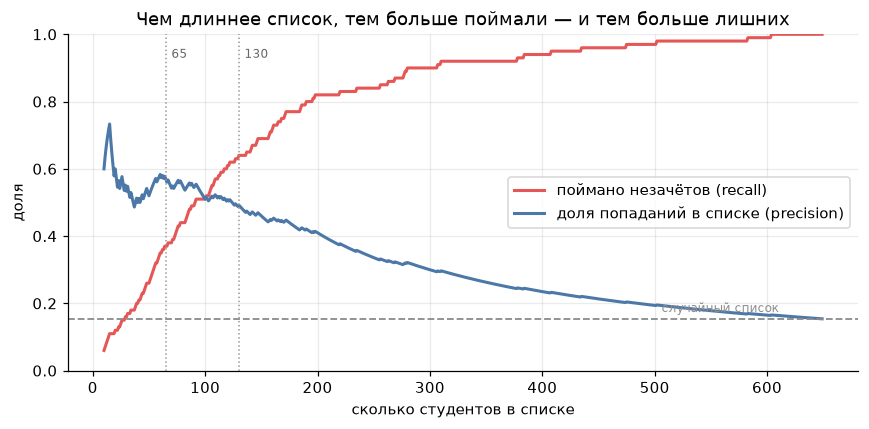

In [31]:
ks = np.arange(10, len(y) + 1)
cum = np.cumsum(y[order])
recall_curve = cum[ks - 1] / total_fail
prec_curve = cum[ks - 1] / ks

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(ks, recall_curve, color=C_FAIL, lw=2,
        label="поймано незачётов (recall)")
ax.plot(ks, prec_curve, color=C_PASS, lw=2,
        label="доля попаданий в списке (precision)")
ax.axhline(base_rate, color=C_NEUTRAL, ls="--", lw=1.2)
ax.text(len(y) * 0.78, base_rate + 0.02, "случайный список", fontsize=8,
        color=C_NEUTRAL)
for k in [65, 130]:
    ax.axvline(k, color="#999", ls=":", lw=1)
    ax.text(k + 5, 0.93, f"{k}", fontsize=8, color="#666")
ax.set_xlabel("сколько студентов в списке")
ax.set_ylabel("доля")
ax.set_ylim(0, 1)
ax.set_title("Чем длиннее список, тем больше поймали — и тем больше лишних")
ax.legend(loc="center right")
plt.show()

In [32]:
prec, rec, thr = precision_recall_curve(y, oof)
f1 = 2 * prec * rec / np.where(prec + rec == 0, 1, prec + rec)
i = int(np.nanargmax(f1[:-1]))
k_f1 = int((oof >= thr[i]).sum())
print(f"справочно, лучший F1 по PR-кривой: {f1[i]:.3f}")
print(f"  ему соответствует список из {k_f1} человек: "
      f"поймано {int(y[order[:k_f1]].sum())} из {total_fail}, "
      f"попаданий {prec[i]:.0%}")

справочно, лучший F1 по PR-кривой: 0.566
  ему соответствует список из 172 человек: поймано 77 из 100, попаданий 45%


**Recall растёт с K, precision падает; рабочая точка — K = 130.**

| K | recall | precision | lift |
|---|---|---|---|
| 30 (5 %) | 0.16 | 0.53 | ×3.5 |
| 65 (10 %) | 0.37 | 0.57 | ×3.7 |
| **130 (20 %)** | **0.64** | **0.49** | **×3.2** |
| 195 (30 %) | 0.82 | 0.42 | ×2.7 |

Удвоение K с 65 до 130 добавляет 27 положительных случаев и 38 отрицательных.
K = 130 даёт recall 0.64 при precision 0.49 — то есть 66 из 130 отобранных
строк относятся к отрицательному классу.

**Precision немонотонна на верхушке**: 0.53 при K = 30 против 0.57 при K = 65.
При 100 положительных случаях на 649 строк точность упорядочивания первых
двух-трёх десятков ограничена размером выборки — ранг внутри верхушки
менее надёжен, чем сам факт попадания в неё.

**F1 приведён справочно**: его максимум 0.563 достигается при K = 163.
F1 неявно приравнивает цену ложноотрицательного и ложноположительного
исхода; в этой задаче они не равны, поэтому K задаётся внешним ограничением
на размер списка, а не максимумом F1.

## 19. Бенчмарк: правило из двух условий

Нижняя граница для модели — правило по двум колонкам, без обучения:
`failures >= 1` **или** `higher == 'no'`. Размер списка у правила фиксирован,
поэтому модель сравнивается с ним при том же K.

In [33]:
rule = ((por["failures"] >= 1) | (por["higher"] == "no")).to_numpy()
k_rule = int(rule.sum())
caught_rule = int(y[rule].sum())
caught_model = int(y[order[:k_rule]].sum())

print(f"ПРАВИЛО без модели: failures >= 1  ИЛИ  higher == 'no'")
print(f"  попадает в список: {k_rule} человек ({k_rule / len(y):.0%} группы)")
print(f"  поймано незачётов: {caught_rule} из {total_fail} "
      f"(recall {caught_rule / total_fail:.0%}, "
      f"precision {caught_rule / k_rule:.0%})\n")
print(f"МОДЕЛЬ при том же размере списка ({k_rule} человек):")
print(f"  поймано незачётов: {caught_model} из {total_fail} "
      f"(recall {caught_model / total_fail:.0%}, "
      f"precision {caught_model / k_rule:.0%})\n")
print(f"разница: {caught_model - caught_rule:+d} студента")

parts_rule = pd.DataFrame([
    {"правило": "был незачёт (failures >= 1)",
     "в списке": int((por.failures >= 1).sum()),
     "поймано": int(y[(por.failures >= 1).to_numpy()].sum())},
    {"правило": "не планирует учиться дальше (higher = no)",
     "в списке": int((por.higher == "no").sum()),
     "поймано": int(y[(por.higher == "no").to_numpy()].sum())},
    {"правило": "любое из двух", "в списке": k_rule, "поймано": caught_rule},
])
parts_rule["precision"] = parts_rule["поймано"] / parts_rule["в списке"]
parts_rule["recall"] = parts_rule["поймано"] / total_fail
print(parts_rule.to_string(index=False))

ПРАВИЛО без модели: failures >= 1  ИЛИ  higher == 'no'
  попадает в список: 136 человек (21% группы)
  поймано незачётов: 63 из 100 (recall 63%, precision 46%)

МОДЕЛЬ при том же размере списка (136 человек):
  поймано незачётов: 64 из 100 (recall 64%, precision 47%)

разница: +1 студента
                                  правило  в списке  поймано  precision  recall
              был незачёт (failures >= 1)       100       49     0.4900  0.4900
не планирует учиться дальше (higher = no)        69       33     0.4783  0.3300
                            любое из двух       136       63     0.4632  0.6300


**Правило даёт 63 из 100 при K = 136, модель при том же K — 65.**

Разрыв в два случая при разбросе метрик порядка нескольких единиц —
то есть на этом K модель и правило неразличимы. Это согласуется с блоком 16:
если два условия воспроизводят результат модели, обученной на 39 признаках,
сигнал сосредоточен в этих же колонках, а не распределён по анкете.

Различие в другом: правило задаёт единственное разбиение 136 / 513 без
упорядочивания внутри частей, а модель ранжирует все 649 строк и допускает
любое K. При K, близком к 136, правило эквивалентно модели и не требует
обучения; при других K оно неприменимо.

## 20. Перенос на другой предмет

Обучение на португальском, применение к математике: 395 строк, те же
33 колонки, доля положительного класса вдвое выше (32.9 % против 15.4 %).

Перед замером — проверка пересечения выборок. Часть студентов изучает оба
предмета, и при их совпадении замер измерял бы не перенос на другой предмет,
а качество на уже виденных строках. Пересечение ищется по 13 колонкам,
идентифицирующим строку.

In [34]:
ID_COLS = ["school", "sex", "age", "address", "famsize", "Pstatus", "Medu",
           "Fedu", "Mjob", "Fjob", "reason", "nursery", "internet"]

key_por = por[ID_COLS].astype(str).agg("|".join, axis=1)
key_mat = mat[ID_COLS].astype(str).agg("|".join, axis=1)
shared = set(key_por) & set(key_mat)
mat_seen = key_mat.isin(shared).to_numpy()

print(f"уникальных ключей: португальский {key_por.nunique()}, "
      f"математика {key_mat.nunique()}")
print(f"общих ключей: {len(shared)}")
print(f"строк математики, совпавших с португальским: {mat_seen.sum()} "
      f"из {len(mat)} ({mat_seen.mean():.0%})")
print(f"строк математики БЕЗ совпадения: {(~mat_seen).sum()}")
print(f"  из них незачётов: {int(y_mat.to_numpy()[~mat_seen].sum())}")

уникальных ключей: португальский 637, математика 391


общих ключей: 366
строк математики, совпавших с португальским: 370 из 395 (94%)
строк математики БЕЗ совпадения: 25
  из них незачётов: 9


In [35]:
y_mat_arr = y_mat.to_numpy()
rows = []
for lvl, drop_g12, Xtr in [("уровень 1 (с контрольными)", False, X1),
                           ("уровень 2 (без контрольных)", True, X2)]:
    Xm, _ = prep(mat, drop_g12=drop_g12)
    Xm = Xm.reindex(columns=Xtr.columns, fill_value=0.0)
    assert list(Xm.columns) == list(Xtr.columns), "колонки не выровнены"
    model = mk_rf_tuned().fit(np.asarray(Xtr, float), y)
    score = model.predict_proba(np.asarray(Xm, float))[:, 1]
    rows.append({
        "режим": lvl,
        "на португальском (проверка)": f"{zero_res[(lvl.split(' (')[0], 'со всеми')][0].mean():.3f}",
        "вся математика": f"{roc_auc_score(y_mat_arr, score):.3f}",
        "только новые люди": f"{roc_auc_score(y_mat_arr[~mat_seen], score[~mat_seen]):.3f}",
    })
print(pd.DataFrame(rows).to_string(index=False))
print(f"\n(«только новые люди» — {(~mat_seen).sum()} студентов, "
      f"{int(y_mat_arr[~mat_seen].sum())} незачётов: оценка очень шумная, "
      f"смотрим на порядок величины, а не на третий знак)")

                      режим на португальском (проверка) вся математика только новые люди
 уровень 1 (с контрольными)                       0.969          0.962             1.000
уровень 2 (без контрольных)                       0.839          0.631             0.646

(«только новые люди» — 25 студентов, 9 незачётов: оценка очень шумная, смотрим на порядок величины, а не на третий знак)


In [36]:
print("Почему рушится режим без контрольных — сравним три фактора на двух предметах:\n")
for col in ["failures", "higher", "school"]:
    rec = {"фактор": ru(col)}
    for name, df_ in [("португальский", por), ("математика", mat)]:
        sh = df_.groupby(col, observed=True)["G3"].apply(lambda s: (s < PASS_MARK).mean())
        rec[f"{name}: разброс долей"] = sh.max() - sh.min()
    print(f"{rec['фактор']:28s} "
          f"португальский Δ={rec['португальский: разброс долей']:.2f}   "
          f"математика Δ={rec['математика: разброс долей']:.2f}")

print("\nдоля незачётов по учебному заведению:")
cmp_school = pd.DataFrame({
    "португальский": por.groupby("school", observed=True)["G3"].apply(
        lambda s: (s < PASS_MARK).mean()),
    "математика": mat.groupby("school", observed=True)["G3"].apply(
        lambda s: (s < PASS_MARK).mean()),
})
print(cmp_school.to_string())

Почему рушится режим без контрольных — сравним три фактора на двух предметах:

прошлые незачёты             португальский Δ=0.55   математика Δ=0.57
планирует учиться дальше     португальский Δ=0.36   математика Δ=0.34
учебное заведение            португальский Δ=0.23   математика Δ=0.05

доля незачётов по учебному заведению:
        португальский  математика
school                           
GP             0.0757      0.3238
MS             0.3009      0.3696


**Переносятся два признака из трёх.**

Проверка пересечения: 370 из 395 строк математики совпали с португальскими
по 13 идентифицирующим колонкам, то есть замер измеряет перенос на другой
предмет, а не на других людей. Непересекающихся строк 25 при 9 положительных
случаях — величина по ним приведена, но статистически неинформативна.

**Уровень 1 переносится (0.96), уровень 2 падает с 0.84 до 0.63.**

Уровень 1 переносится тривиально: `G1` и `G2` — оценки по тому же предмету.
ROC-AUC 1.000 на 25 непересекающихся строках при 9 положительных случаях
статистически неинформативен.

Падение уровня 2 локализуется в одном признаке — `school`. Разброс долей
по школам: 0.23 на португальском, 0.05 на математике. У двух других
признаков он сохраняется: `failures` 0.55 → 0.57, `higher` 0.36 → 0.34.
То есть `school` кодирует свойство пары «предмет × школа», а не свойство
студента, и вне португальского теряет разделяющую способность.

Из трёх признаков переносятся два. Модель, обученную на одном предмете,
нельзя применять к другому без повторного замера.

## 21. Сводка результатов

Рабочая конфигурация: уровень 2 (без `G1`, `G2`), смесь трёх моделей
по рангам с весами 0.4 / 0.3 / 0.3. Метрики — на 30 разбиениях с зерном 1,
независимых от тех, на которых конфигурация отбиралась.

| Конфигурация | ROC-AUC | PR-AUC |
|---|---|---|
| Лес из коробки | 0.830 ± 0.032 | 0.494 ± 0.081 |
| Настроенный лес | 0.836 ± 0.035 | 0.495 ± 0.081 |
| **Смесь трёх моделей** | **0.843 ± 0.036** | **0.515 ± 0.076** |
| Уровень 1, справочно | 0.966 ± 0.010 | 0.844 ± 0.059 |

Отсечение K = 130 (20 % выборки): recall 0.64, precision 0.49, lift ×3.2.
Бенчмарк без обучения при K = 136: 63 против 65 у модели.

| Признак | Направление | Разделение | Перенос на математику |
|---|---|---|---|
| `school` | MS выше | 30 % против 7.6 % | нет: 37 % против 32 % |
| `failures` | больше — выше | 9 % → 46 % → 64 % | да |
| `higher` | `no` выше | 48 % против 12 % | да |

Границы применимости: уровень 2 при переносе на математику даёт 0.631
против 0.843 на португальском; из трёх признаков переносятся два.
Изложение тех же результатов без технических терминов — в `DEFENSE.md`.

## 22. Выгрузка модели

Финальная смесь обучается на всех 649 строках и сохраняется в `models/`.
Реализация — в `src/scoring.py`; ноутбук импортирует её, а не дублирует.
Внешние потребители используют те же три функции.

In [37]:
from scoring import fit_blend, save_model, load_model, predict_risk, explain  # noqa: E402

TOP3_SOURCE = list(dict.fromkeys(source_col(c) for c in TOP3))

final_model = fit_blend(por, weights=BLEND_W, random_state=RANDOM_STATE,
                        rf_params=BEST_RF)
final_model["top_factors"] = TOP3_SOURCE
final_model["oof_roc_auc"] = float(confirm_res["смесь трёх моделей"][0].mean())
final_model["recommended_list_size"] = 130

saved_to = save_model(final_model, MODELS_DIR)
print(f"сохранено: {saved_to.relative_to(ROOT)} "
      f"({saved_to.stat().st_size / 1e6:.1f} МБ)")
print(f"признаков в модели: {len(final_model['columns'])}")
print(f"три фактора: {final_model['top_factors']}")

сохранено: models\blend.joblib (4.5 МБ)
признаков в модели: 39
три фактора: ['school', 'failures', 'higher']


In [38]:
loaded = load_model(MODELS_DIR)
risk = predict_risk(por, loaded)

assert risk.shape == (len(por),)
assert 0 < risk.min() and risk.max() <= 1.0
print(f"predict_risk вернул {len(risk)} оценок в диапазоне "
      f"{risk.min():.3f}–{risk.max():.3f}")

top_list = por.assign(риск=risk).nlargest(10, "риск")[
    ["school", "sex", "age", "failures", "higher", "absences", "риск"]]
print("\nдесять самых рискованных по финальной модели:")
print(top_list.to_string())

card = explain(por, int(np.argmax(risk)), loaded)
print("\nкарточка самого рискованного студента:")
print(json.dumps(card, ensure_ascii=False, indent=2))

predict_risk вернул 649 оценок в диапазоне 0.002–1.000

десять самых рискованных по финальной модели:
    school sex  age  failures higher  absences   риск
563     MS   M   17         1    yes         0 1.0000
567     MS   M   18         1     no         0 0.9985
279     GP   M   22         3     no        12 0.9969
605     MS   F   19         1     no         0 0.9954
500     MS   M   17         1     no        12 0.9938
610     MS   F   19         3     no         0 0.9923
590     MS   F   18         2    yes         3 0.9908
465     MS   F   18         1    yes         9 0.9892
432     MS   F   17         1     no         0 0.9877
583     MS   F   18         1     no         0 0.9861



карточка самого рискованного студента:
{
  "позиция": 563,
  "риск": 1.0,
  "место_в_очереди": 1,
  "размер_группы": 649,
  "факторы": {
    "school": {
      "название": "учебное заведение",
      "значение": "MS"
    },
    "failures": {
      "название": "прошлые незачёты",
      "значение": 1
    },
    "higher": {
      "название": "планирует учиться дальше",
      "значение": "yes"
    }
  },
  "оговорка": "Значения признаков описывают статистическую связь с целевой переменной и не являются утверждением о причинности."
}


In [39]:
print("Проверка воспроизводимости и отсутствия утечки:\n")
assert "G3" not in final_model["columns"], "УТЕЧКА: G3 в сохранённой модели"
assert not any(c.startswith("G1") or c.startswith("G2")
               for c in final_model["columns"]), "УТЕЧКА: G1/G2 в рабочей модели"
assert confirm_res["смесь трёх моделей"][0].mean() < 0.99, "подозрительно высокий ROC-AUC"

summary = pd.DataFrame([
    {"пункт": "базовый лес, без контрольных",
     "ROC-AUC": short(confirm_res["базовый лес"][0])},
    {"пункт": "настроенный лес",
     "ROC-AUC": short(confirm_res["настроенный лес"][0])},
    {"пункт": "смесь трёх моделей (финал)",
     "ROC-AUC": short(confirm_res["смесь трёх моделей"][0])},
    {"пункт": "с контрольными (недостижимо вовремя)",
     "ROC-AUC": short(levels_res[("уровень 1 (с контрольными)", "случайный лес")][0])},
])
print(summary.to_string(index=False))
print(f"\nсписок из 130 человек ловит {int(y[order[:130]].sum())} незачётов из {total_fail}")
print("Все проверки пройдены.")

Проверка воспроизводимости и отсутствия утечки:

                               пункт       ROC-AUC
        базовый лес, без контрольных 0.830 ± 0.032
                     настроенный лес 0.836 ± 0.035
          смесь трёх моделей (финал) 0.843 ± 0.036
с контрольными (недостижимо вовремя) 0.966 ± 0.010

список из 130 человек ловит 64 незачётов из 100
Все проверки пройдены.
